# Compute correlations with metadata
## Setup
### Import packages

In [53]:
import logging
import re
import textwrap
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import gurobipy as gp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import optlang
import pandas as pd
import seaborn as sns
import sympy
from cobra import DictList, Reaction
from cobra.flux_analysis.variability import (find_blocked_reactions,
                                             flux_variability_analysis)
from cobra.util.array import create_stoichiometric_matrix, nullspace
from mpl_toolkits.axes_grid1 import make_axes_locatable
from rbc_gem_utils import (ANNOTATION_PATH, COBRA_CONFIGURATION, CURATION_PATH,
                           DATABASE_PATH, GEM_NAME, INTERIM_PATH,
                           PARAMETERIZATION_PATH, PROCESSED_PATH, ROOT_PATH,
                           build_string, check_database_version_online,
                           check_version, compare_tables, explode_column,
                           get_annotation_df, read_cobra_model, read_rbc_model,
                           show_versions, split_string, visualize_comparison,
                           write_cobra_model)
from rbc_gem_utils.analysis.overlay import *
from rbc_gem_utils.database.uniprot import (UNIPROT_DB_TAG,
                                            UNIPROT_ISOFORM_ID_RE,
                                            UNIPROT_PATH)
from rbc_gem_utils.qc import reset_reaction_bounds, reset_subsystem_groups
from rbc_gem_utils.util import (AVOGADRO_NUMBER, DEFAULT_DRY_MASS_PER_CELL,
                                convert_gDW_to_L, convert_L_to_gDW,
                                ensure_iterable, log_msg, strip_plural)
from rbc_gem_utils.visualization import cmap_map
from scipy.cluster.hierarchy import linkage
from scipy.stats import spearmanr
from sklearn.metrics import r2_score
from sympy import parse_expr

gp.setParam("OutputFlag", 0)
gp.setParam("LogToConsole", 0)

# Show versions of notebook
show_versions()
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"


Package Information
-------------------
rbc-gem-utils 0.0.1

Dependency Information
----------------------
beautifulsoup4                       4.12.3
bio                                 missing
cobra                                0.29.1
depinfo                               2.2.0
gurobipy                             11.0.3
matplotlib                           3.10.0
matplotlib-venn                       1.1.1
memote                               0.17.0
networkx                              3.4.2
notebook                              7.3.2
openpyxl                              3.1.5
pandas                                2.2.3
pre-commit                            4.1.0
rbc-gem-utils[database,network,vis] missing
requests                             2.32.3
scipy                                1.15.1
seaborn                              0.13.2

Build Tools Information
-----------------------
pip          24.2
setuptools 75.1.0
wheel      0.44.0

Platform Information
-------------------

### Define configuration
#### COBRA Configuration

In [54]:
COBRA_CONFIGURATION.solver = "gurobi"
# Set bound defaults much larger to prevent model loading issues
COBRA_CONFIGURATION.bounds = (-1e8, 1e8)
COBRA_CONFIGURATION

Attribute,Description,Value
solver,Mathematical optimization solver,gurobi
tolerance,"General solver tolerance (feasibility, integrality, etc.)",1e-07
lower_bound,Default reaction lower bound,-100000000.0
upper_bound,Default reaction upper bound,100000000.0
processes,Number of parallel processes,127
cache_directory,Path for the model cache,C:\Users\Alicia Key\AppData\Local\opencobra\cobrapy\Cache
max_cache_size,Maximum cache size in bytes,104857600
cache_expiration,Model cache expiration time in seconds (if any),None


## Load RBC-GEM model

In [55]:
model_id = "RBC3P_expanded"

data_path = Path("../../../../data/analysis/OVERLAY").resolve()
root_path = Path("../../../..").resolve()
results_path = root_path / "data" / "processed" / model_id / "OVERLAY"
results_path.mkdir(exist_ok=True, parents=True)

imagetype = "svg"
transparent = True
save_figures = True

dataset_name = "RBComics_G6PD"
pcmodel_dirpath = data_path / model_id
dataset_path = results_path / dataset_name
dataset_models_dirpath = dataset_path / "pcmodels"

sample_prefix, time_prefix = ("S", "D")
# Integers are easier to work with for time points
timepoints = [10, 23, 42]

model_filename = pcmodel_dirpath / f"{model_id}.xml"
model = read_cobra_model(filename=model_filename)
pcmodel_filename = pcmodel_dirpath / f"{model_id}_PC.xml"
pcmodel = load_overlay_model(filename=pcmodel_filename)

# For this workflow, shut off complex dilution reactions at the start
for cplx_dilution in pcmodel.reactions.query(lambda x: isinstance(x, ComplexDilution)):
    cplx_dilution.bounds = (0, 0)

pcmodel

Name,RBC3P_expanded_PC
Memory address,23cf7ee6870
Number of metabolites,515
Number of reactions,972
Number of genes,107
Number of groups,12
Objective expression,1.0*NaKt - 1.0*NaKt_reverse_db47e
Compartments,"cytosol, extracellular space, protein compartment"


## Load pcFVA generated results

In [56]:
pcfva_results_dirpath = dataset_path / "pcFVA" 
corr_results_dirpath = dataset_path / "correlations"
print(pcfva_results_dirpath)
print(corr_results_dirpath)

D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\pcFVA
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\correlations


In [57]:
# Test to see if results were recently generated in this run, otherwise load DataFrame of generated results

try:
    assert not df_pcfva_all.empty
except (NameError, AssertionError):
    df_pcfva_all = pd.read_csv(
        f"{pcfva_results_dirpath}/{pcmodel.id}_FVAresults_ALL.tsv",
        sep="\t",
        index_col=None,
    )

df_pcfva_all

,reactions,optimum,model,minimum,maximum
0,ADA,0.00,RBC3P_expanded_PC_Mean_D10,0.0,4.237475
1,ADA,0.00,RBC3P_expanded_PC_Mean_D23,0.0,4.240071
2,ADA,0.00,RBC3P_expanded_PC_Mean_D42,0.0,4.238002
3,ADA,0.00,RBC3P_expanded_PC_Median_D10,0.0,4.239498
4,ADA,0.00,RBC3P_expanded_PC_Median_D23,0.0,4.240640
...,...,...,...,...,...
7931515,TPI,0.99,RBC3P_expanded_PC_S00649_D23,0.0,0.021197
7931516,TPI,0.99,RBC3P_expanded_PC_S00649_D42,0.0,0.021237
7931517,TPI,0.99,RBC3P_expanded_PC_S00650_D10,0.0,0.020971
7931518,TPI,0.99,RBC3P_expanded_PC_S00650_D23,0.0,0.020753


In [58]:
def get_sample_from_id(model_id, sample_prefix=""):
    sample = model_id.rsplit("_", 2)[-2]
    try:
        return int(sample.replace(sample_prefix, ""))
    except ValueError:
        return sample


def get_time_from_id(model_id, time_prefix=""):
    time = model_id.rsplit("_", 2)[-1]
    try:
        return int(time.replace(time_prefix, ""))
    except ValueError:
        return time

In [59]:
list_of_pcmodels = list(df_pcfva_all["model"].unique())
operation_model_ids = sorted(
    [
        x
        for x in list_of_pcmodels
        if not isinstance(get_sample_from_id(x, sample_prefix), (int, float))
    ],
    key=lambda x: (
        get_sample_from_id(x, sample_prefix),
        get_time_from_id(x, time_prefix),
    ),
)
operations = set([get_sample_from_id(x, sample_prefix) for x in operation_model_ids])
operations

{'Mean', 'Median'}

In [60]:
enzyme_total_suffix = DEFAULT_ENZYME_TOTAL_SUFFIX
min_reaction_list = model.reactions.query(lambda x: x.gene_reaction_rule).list_attr(
    "id"
)
enzymes_list = pcmodel.reactions.query(
    lambda x: x.id.startswith(f"ENZDL_enzyme_") and f"{enzyme_total_suffix}" in x.id
).list_attr("id")
reaction_enzymes_map = {
    rid: tuple(
        pcmodel.reactions.query(
            lambda x: x.id.startswith(f"ENZDL_enzyme_{rid}_")
        ).list_attr("id")
    )
    for rid in min_reaction_list
}
enzyme_reaction_map = {
    enzyme: rid for rid, enzymes in reaction_enzymes_map.items() for enzyme in enzymes
}
if not enzymes_list:
    enzymes_list = [
        enzyme
        for enzyme, rid in enzyme_reaction_map.items()
        if rid in min_reaction_list
    ]
min_reaction_list += enzymes_list
print(
    f"Number of reactions minimize/maximize (minimum): {len(min_reaction_list)} / {len(pcmodel.reactions)}"
)

Number of reactions minimize/maximize (minimum): 122 / 972


### Parse main results into smaller DataFrames
#### Seperate by reaction variable types

In [61]:
# Initialize entries with prefixes used for seperating DataFrames
dict_of_dataframes_types = {
    "reactions": None,
    "proteins": "PROTDL",
    # "complexes": "CPLXFM",
    # "complex_dilutions": "CPLXDL",
    "enzymes": "ENZDL",
    # "enzyme_formation": "ENZFM",
    "budgets": "PBDL",
    "relaxation": "RELAX",
}
for key, prefix in dict_of_dataframes_types.copy().items():
    if prefix:
        df = df_pcfva_all[
            df_pcfva_all["reactions"].apply(lambda x: x.startswith(prefix))
        ]
    else:
        df = df_pcfva_all[
            df_pcfva_all["reactions"].apply(lambda x: x in model.reactions)
        ]
    dict_of_dataframes_types[key] = df.copy()

dict_of_dataframes_types;

#### Seperate by optimum value

In [62]:
# dict_of_dataframes_opt = {
#     optimum: df_pcfva_all[df_pcfva_all["optimum"] == optimum].copy()
#     for optimum in df_pcfva_all["optimum"].unique()
# }
# print(list(dict_of_dataframes_opt))

#### Seperate by model

In [63]:
# dict_of_dataframes_model = {
#     model_id: df_pcfva_all[df_pcfva_all["model"] == model_id].copy()
#     for model_id in df_pcfva_all["model"].unique()
# }
# print(list(dict_of_dataframes_model))

### Create DataFrame for correlation calculations
#### Get maximum reaction fluxes and associated expression values

In [64]:
groupby_list = ["model", "reactions"]
always_expression_independent = [
    r.id for r in model.reactions.query(lambda x: not x.boundary and not x.genes)
]
print(
    f"Number of reactions w/o genes, always expression independent: {len(always_expression_independent)}"
)
always_expression_independent;

Number of reactions w/o genes, always expression independent: 7


##### Get maximum reaction flux

In [65]:
# Get the maximum value of the reaction flux in each direction, regardless of percent optimum
df = dict_of_dataframes_types["reactions"].copy()
df = df.groupby(groupby_list)[["minimum", "maximum"]].agg(
    {
        "minimum": "min",
        "maximum": "max",
    }
)
df_max_flux_per_model = df.abs().max(axis=1)
df_max_flux_per_model.name = "Flux"
df_max_flux_per_model

model                         reactions
RBC3P_expanded_PC_Mean_D10    ADA          4.237475
                              ADEt         0.438268
                              ADK1         0.438268
                              ADNK1        0.438268
                              ADNt         4.096882
                                             ...   
RBC3P_expanded_PC_S00650_D42  SPODM        3.140980
                              TALA         0.697196
                              TKT1         0.697196
                              TKT2         0.697196
                              TPI          0.828974
Name: Flux, Length: 178092, dtype: float64

##### Get maximum flux range

In [66]:
# Determine flux range
df = dict_of_dataframes_types["reactions"].copy()
df["Range"] = df["maximum"] - df["minimum"]
df_flux_range_per_model = df.groupby(groupby_list)["Range"].max()
df_flux_range_per_model

model                         reactions
RBC3P_expanded_PC_Mean_D10    ADA          4.237475
                              ADEt         0.438268
                              ADK1         0.438268
                              ADNK1        0.438268
                              ADNt         4.535150
                                             ...   
RBC3P_expanded_PC_S00650_D42  SPODM        3.140980
                              TALA         1.363429
                              TKT1         1.363429
                              TKT2         1.363429
                              TPI          0.828974
Name: Range, Length: 178092, dtype: float64

##### Get maximum expression

In [67]:
# Determine expression association with reaction
df = dict_of_dataframes_types["enzymes"].copy()
df["reactions"] = df["reactions"].apply(lambda x: enzyme_reaction_map[x])
df_max_enzyme_per_model = df.groupby(groupby_list)["maximum"].max()
df_max_enzyme_per_model.name = "Expression"
df_max_enzyme_per_model

model                         reactions
RBC3P_expanded_PC_Mean_D10    ADA           47.990221
                              ADEt          63.799870
                              ADK1         161.527417
                              ADNK1         48.810568
                              ADNt          34.935398
                                              ...    
RBC3P_expanded_PC_S00650_D42  SPODM         99.512221
                              TALA          17.826387
                              TKT1           6.440342
                              TKT2           6.440342
                              TPI           41.196502
Name: Expression, Length: 111996, dtype: float64

##### Merge into one DataFrame

In [68]:
df_reaction_flux_expression = (
    pd.merge(
        df_max_flux_per_model,
        df_flux_range_per_model,
        left_index=True,
        right_index=True,
    )
    .merge(df_max_enzyme_per_model, left_index=True, right_index=True)
    .reset_index(drop=False)
)
df_reaction_flux_expression

,model,reactions,Flux,Range,Expression
0,RBC3P_expanded_PC_Mean_D10,ADA,4.237475,4.237475,47.990221
1,RBC3P_expanded_PC_Mean_D10,ADEt,0.438268,0.438268,63.799870
2,RBC3P_expanded_PC_Mean_D10,ADK1,0.438268,0.438268,161.527417
3,RBC3P_expanded_PC_Mean_D10,ADNK1,0.438268,0.438268,48.810568
4,RBC3P_expanded_PC_Mean_D10,ADNt,4.096882,4.535150,34.935398
...,...,...,...,...,...
111991,RBC3P_expanded_PC_S00650_D42,SPODM,3.140980,3.140980,99.512221
111992,RBC3P_expanded_PC_S00650_D42,TALA,0.697196,1.363429,17.826387
111993,RBC3P_expanded_PC_S00650_D42,TKT1,0.697196,1.363429,6.440342
111994,RBC3P_expanded_PC_S00650_D42,TKT2,0.697196,1.363429,6.440342


### Define helper methods

In [69]:
def prepare_correlation_df(df, pvalue_tol):
    df["pvalue"] = df["pvalue"].apply(
        lambda x: -np.log10(x if x >= pvalue_tol else pvalue_tol)
    )
    df = df.sort_values(["pvalue", "rho"], ascending=[False, False])
    return df


def plot_correlations(
    df, ax=None, histx=True, histy=True, colorbar=True, vertical_lines=None, **kwargs
):
    # Define figure if no axes provided.
    scatter_inch = kwargs.get("scatter_inch", 5.0)
    hist_inch = kwargs.get("hist_inch", 1.0)
    hist_pad = kwargs.get("hist_pad", 0.25)
    if ax is None:
        _, ax = plt.subplots(
            nrows=1,
            ncols=1,
            figsize=(
                scatter_inch + (hist_inch + hist_pad if histy else 0),
                scatter_inch + (hist_inch + hist_pad if histx else 0),
            ),
        )
    # X-axis is rho, Y-axis is expected as -log10(pvalue) from correlation prep
    xy = {"x": "rho", "y": "pvalue"}
    limits = {
        "x": (kwargs.get("xmin", -1.0), kwargs.get("xmax", 1.0)),
        "y": (kwargs.get("ymin", 0.0), kwargs.get("ymax", df[xy["y"]].max())),
    }
    pads = {
        axis: kwargs.get(f"{axis}pad", (limits[axis][1] - limits[axis][0]) / 2 / 20)
        for axis in list(xy)
    }
    cmap = kwargs.get("cmap", "viridis")
    zorder = kwargs.get("zorder", 2)
    edgecolor = kwargs.get("edgecolor", "black")
    edgewidth = kwargs.get("edgewidth", 0.5)
    scatter = ax.scatter(
        xy["x"],
        xy["y"],
        data=df,
        c=kwargs.get("c", xy["y"]),
        s=kwargs.get("s", 40),
        zorder=zorder,
        edgecolor=edgecolor,
        linewidth=edgewidth,
        cmap=mpl.colormaps.get_cmap(cmap) if isinstance(cmap, str) else cmap,
        norm=mpl.colors.Normalize(
            vmin=limits["y"][0] - pads["y"], vmax=limits["y"][1] + pads["y"]
        ),
    )
    ax.set_xlabel(r"Spearman Correlation $(\rho)$", fontdict={"size": "xx-large"})
    ax.set_ylabel("-log$_{10}$(p-value)", fontdict={"size": "xx-large"})
    ax.set_xlim((limits["x"][0] - pads["x"], limits["x"][1] + pads["x"]))
    ax.set_ylim((limits["y"][0] - pads["y"], limits["y"][1] + pads["y"]))

    major_ticks = {axis: kwargs.get(f"{axis}tick_major") for axis in list(xy)}
    minor_ticks = {
        axis: kwargs.get(
            f"{axis}tick_minor",
            major_ticks[axis] / 2 if major_ticks[axis] is not None else None,
        )
        for axis in list(xy)
    }
    for axis in list(xy):
        if major_ticks[axis] is not None:
            getattr(ax, f"{axis}axis").set_major_locator(
                mpl.ticker.MultipleLocator(major_ticks[axis])
            )
        if minor_ticks[axis] is not None:
            getattr(ax, f"{axis}axis").set_minor_locator(
                mpl.ticker.MultipleLocator(minor_ticks[axis])
            )
        ax.tick_params(axis=axis, labelsize="large")

    if vertical_lines:
        for lineval, (lineprops, textprops) in vertical_lines.items():
            if lineprops:
                ax.vlines(
                    x=lineval,
                    ymin=limits["y"][0] - pads["y"],
                    ymax=limits["y"][1] + pads["y"],
                    **lineprops,
                )
            if textprops:
                ax.text(x=lineval + pads["x"] / 2, transform=ax.transData, **textprops)

    if kwargs.get("grid", False):
        ax.grid(True, **dict(which="both", alpha=0.75))

    if colorbar:
        cax = ax.inset_axes(
            [
                limits["x"][0] - pads["x"],  # lower left corner xpos
                limits["y"][0] - pads["y"],  # lower left corner ypos
                pads["x"],  # width of colorbar
                limits["y"][1]
                + pads["y"]
                + pads[
                    "y"
                ],  # height of colorbar, need extra ypad to make up for lowering ypos
            ],
            transform=ax.transData,
        )
        cbar = ax.get_figure().colorbar(scatter, cax=cax)
        cax.set_ylim((limits["y"][0] - pads["y"], limits["y"][1] + pads["y"]))
        cax.set_xticks([])
        cax.set_yticks([])

    ax_histx = None
    ax_histy = None
    if histx or histy:
        divider = make_axes_locatable(ax)
        # Histogram axes
        ax_histx = (
            divider.append_axes("top", hist_inch, pad=hist_pad, sharex=ax)
            if histx
            else None
        )
        ax_histy = (
            divider.append_axes("right", hist_inch, pad=hist_pad, sharey=ax)
            if histy
            else None
        )

        for axis, ax_hist in zip(list(xy), [ax_histx, ax_histy]):
            if ax_hist is None:
                continue
            binwidth = kwargs.get(
                f"{axis}binwidth",
                (
                    minor_ticks[axis]
                    if minor_ticks[axis] is not None
                    else major_ticks[axis]
                ),
            )
            counts, bins, patches = ax_hist.hist(
                df[xy[axis]],
                bins=np.arange(limits[axis][0], limits[axis][1] + binwidth, binwidth),
                orientation="vertical" if axis == "x" else "horizontal",
                zorder=zorder,
                edgecolor=edgecolor,
                linewidth=edgewidth,
            )
            other = "y" if axis == "x" else "x"
            ax_hist.tick_params(
                axis=axis, **{f"label{'bottom' if axis == 'x' else 'left'}": False}
            )
            ax_hist.tick_params(axis=other, labelsize="large")
            getattr(ax_hist, f"set_{other}label")("Frequency", fontsize="large")

            tick_major_int = kwargs.get(f"hist{axis}_{other}tick_major")
            if tick_major_int is not None:
                getattr(ax_hist, f"{other}axis").set_major_locator(
                    mpl.ticker.MultipleLocator(tick_major_int)
                )
                getattr(ax_hist, f"{other}axis").set_minor_locator(
                    mpl.ticker.MultipleLocator(tick_major_int / 2)
                )
            getattr(ax_hist, f"set_{other}lim")((0, max(counts) * 1.1))
            if kwargs.get("grid", False):
                ax_hist.grid(True, **dict(which="both", alpha=0.75))

            if vertical_lines and (axis == "x" and ax_hist is not None):
                for lineval, (lineprops, _) in vertical_lines.items():
                    if lineprops:
                        ax_hist.vlines(
                            x=lineval, ymin=0.0, ymax=max(counts) * 1.1, **lineprops
                        )

    return ax, ax_histx, ax_histy

### Create subgroups of models 

In [70]:
# Don't include mean/median in correlation calculations
model_groups = {
    "ALL": [
        x
        for x in list_of_pcmodels
        if not any([op.capitalize() in x for op in operations])
    ],
    "OPERATIONS": operation_model_ids,
}
# model_groups.update({
#     f"{time_prefix}{time}": [x for x in model_groups["ALL"] if x.endswith(f"{time_prefix}{time}")]
#     for time in timepoints
# })
list(model_groups)

['ALL', 'OPERATIONS']

### Compute correlations with metadata

In [71]:
df_metadata = pd.read_csv(
    f"{data_path}/{dataset_name}/Proteomics_Metadata.tsv", sep="\t", index_col=0
)
df_metadata = df_metadata.convert_dtypes()

numeric_metadata_columns = df_metadata.select_dtypes(include="number").columns
other_metadata_columns = df_metadata.select_dtypes(exclude="number").columns
# Map to models
df_pcmodel_meta = pd.DataFrame.from_dict(
    {
        pcmodel_id: pcmodel_id.replace(f"{pcmodel.id}_", "").split("_")[0]
        for pcmodel_id in list_of_pcmodels
    },
    orient="index",
    columns=["donor"],
)
sample_ids = set(df_pcmodel_meta["donor"].unique())
# Handle models generated using operations such as mean, median, and quantile
to_concat = []
operations = set(
    [
        get_sample_from_id(x, sample_prefix)
        for x in list_of_pcmodels
        if isinstance(get_sample_from_id(x, sample_prefix), str)
    ]
)
for op in operations:
    if op in sample_ids:
        df = getattr(
            df_metadata.loc[list(sample_ids.difference(operations))],
            op.lower(),
        )(axis=0, numeric_only=True)
        df.name = op
        to_concat.append(df)


df_metadata = pd.concat([df_metadata.T] + to_concat, axis=1).T
df_pcmodel_meta = df_pcmodel_meta.merge(df_metadata, left_on="donor", right_index=True)
df_pcmodel_meta

,donor,Day,AS,Gender,DONDB.ABO_RH,RBCOmics.Race.Ethnicity.Group,Age,BMI,Weight,Height,...,Adjusted.Osmotic.Hemolysis,Adjusted.Oxidative.Hemolysis,CBC.WBC,CBC.RBC,CBC.HGB,CBC.HCT,CBC.MCV,CBC.RDW,CBC.PLT,Ferritin
RBC3P_expanded_PC_Mean_D10,Mean,25.0,<NA>,<NA>,<NA>,<NA>,50.589071,27.819681,182.078689,67.719126,...,31.85724,33.876448,6.52903,4.754671,13.971767,42.21636,89.127007,13.921851,245.022297,43.032298
RBC3P_expanded_PC_Mean_D23,Mean,25.0,<NA>,<NA>,<NA>,<NA>,50.589071,27.819681,182.078689,67.719126,...,31.85724,33.876448,6.52903,4.754671,13.971767,42.21636,89.127007,13.921851,245.022297,43.032298
RBC3P_expanded_PC_Mean_D42,Mean,25.0,<NA>,<NA>,<NA>,<NA>,50.589071,27.819681,182.078689,67.719126,...,31.85724,33.876448,6.52903,4.754671,13.971767,42.21636,89.127007,13.921851,245.022297,43.032298
RBC3P_expanded_PC_Median_D10,Median,23.0,<NA>,<NA>,<NA>,<NA>,53.0,26.602783,176.0,68.0,...,30.035009,33.81433,6.2,4.71,13.9,42.05,89.6,13.675,239.0,27.0
RBC3P_expanded_PC_Median_D23,Median,23.0,<NA>,<NA>,<NA>,<NA>,53.0,26.602783,176.0,68.0,...,30.035009,33.81433,6.2,4.71,13.9,42.05,89.6,13.675,239.0,27.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RBC3P_expanded_PC_S00650_D23,S00650,23,AS1,F,O+,CAUCASIAN,60,30.102509,198,68,...,42.290107,<NA>,5.91,4.62,13.8,42.3,91.6,13.6,199.0,23.0
RBC3P_expanded_PC_S00650_D23,S00650,42,AS1,F,O+,CAUCASIAN,60,30.102509,198,68,...,42.290107,<NA>,5.91,4.62,13.8,42.3,91.6,13.6,199.0,23.0
RBC3P_expanded_PC_S00650_D42,S00650,10,AS1,F,O+,CAUCASIAN,60,30.102509,198,68,...,42.290107,<NA>,5.91,4.62,13.8,42.3,91.6,13.6,199.0,23.0
RBC3P_expanded_PC_S00650_D42,S00650,23,AS1,F,O+,CAUCASIAN,60,30.102509,198,68,...,42.290107,<NA>,5.91,4.62,13.8,42.3,91.6,13.6,199.0,23.0


#### Identify all possible pairs of columns for correlation computations

In [72]:
for i, metadata_col in enumerate(numeric_metadata_columns, start=1):
    print(f"{i}:\t{metadata_col}")

1:	Day
2:	Age
3:	BMI
4:	Weight
5:	Height
6:	Hemolysis.volume
7:	Hemolysis.hct
8:	Hemolysis.storage_total_hb
9:	Hemolysis.storage_pct_hemol
10:	Hemolysis.pink_total_hb
11:	Hemolysis.pink_pct_hemol
12:	Recall.Transfer.Storage.Hemolysis
13:	Recall.Transfer.Osmotic.Hemolysis
14:	Recall.Transfer.Oxidative.Hemolysis
15:	Adjusted.Storage.Hemolysis
16:	Adjusted.Osmotic.Hemolysis
17:	Adjusted.Oxidative.Hemolysis
18:	CBC.WBC
19:	CBC.RBC
20:	CBC.HGB
21:	CBC.HCT
22:	CBC.MCV
23:	CBC.RDW
24:	CBC.PLT
25:	Ferritin


#### Compute all pairs of correlations
Can take a significant amount of time the first time computed.

In [73]:
verbose = False
display_top_nhits = 10
reaction_list = list(df_reaction_flux_expression["reactions"].unique())
corr_results_dirpath.mkdir(exist_ok=True, parents=True)

In [74]:
# Keep off to use previously computed results. Does not work if results not previously computed
run_computations = True
group_name = "ALL"
metadata_columns_for_corr = [
    # Comment/Uncomment to control desired columns
    "Age",
    "BMI",
    "Weight",
    "Height",
    "Hemolysis.volume",
    "Hemolysis.hct",
    "Hemolysis.storage_total_hb",
    "Hemolysis.storage_pct_hemol",
    "Hemolysis.pink_total_hb",
    "Hemolysis.pink_pct_hemol",
    "Recall.Transfer.Storage.Hemolysis",
    "Recall.Transfer.Osmotic.Hemolysis",
    "Recall.Transfer.Oxidative.Hemolysis",
    "Adjusted.Storage.Hemolysis",
    "Adjusted.Osmotic.Hemolysis",
    "Adjusted.Oxidative.Hemolysis",
    "CBC.WBC",
    "CBC.RBC",
    "CBC.HGB",
    "CBC.HCT",
    "CBC.MCV",
    "CBC.RDW",
    "CBC.PLT",
    "Ferritin",
]

if group_name in operations or group_name == "OPERATIONS":
    raise Exception("Cannot use models created using data from statistical operations.")

group_model_list = model_groups[group_name]
group_results_dir = Path(f"{corr_results_dirpath}/{group_name}")
group_results_dir.mkdir(exist_ok=True, parents=True)

metadata_rankings_group_dict = defaultdict(dict)
for metadata_col in metadata_columns_for_corr:
    for column_pair in [("Flux", metadata_col), ("Expression", metadata_col)]:
        filepath = Path(f"{group_results_dir}/{column_pair[0]}_{column_pair[1]}.tsv")
        if filepath.exists():
            print(
                "Already computed correlations between '{}' and '{}' for '{}' models".format(
                    *column_pair, group_name
                )
            )
            df_correlations = pd.read_csv(f"{filepath}", sep="\t", index_col=0)
            df_correlations = df_correlations.loc[reaction_list]
        elif run_computations:
            print(
                "========================================================================="
            )
            print(
                "Computing correlations between '{}' and '{}' for '{}' models".format(
                    *column_pair, group_name
                )
            )
            print(
                "========================================================================="
            )
            correlations_dict = defaultdict(dict)
            metadata_cols = [
                col for col in column_pair if col in numeric_metadata_columns
            ]
            if any(metadata_cols):
                df_meta = df_pcmodel_meta.loc[:, metadata_cols].dropna()
                model_list = [m for m in group_model_list if m in df_meta.index]
            else:
                model_list = group_model_list.copy()
            for rid in reaction_list:
                df = df_reaction_flux_expression[
                    df_reaction_flux_expression["reactions"] == rid
                ]
                df = df.drop("reactions", axis=1)
                df = df.set_index("model")
                # Add metadata columns if needed
                if any(metadata_cols):
                    df = df.merge(
                        df_meta, left_index=True, right_index=True, how="inner"
                    ).dropna(axis=0)
                # Expected warnings emitted are due to constant input array, in which the correlation coefficient is not defined. Corresponds to the nan values.
                with warnings.catch_warnings(action="ignore"):
                    rho, pvalue = spearmanr(df.loc[model_list, list(column_pair)])
                correlations_dict[rid]["rho"] = rho
                correlations_dict[rid]["pvalue"] = pvalue
                if verbose:
                    print(f"For reaction {rid}: rho={rho}, p={pvalue}")
            df_correlations = pd.DataFrame.from_dict(correlations_dict, orient="index")
            df_correlations.to_csv(f"{filepath}", sep="\t", index=True)
        else:
            continue

        metadata_rankings_group_dict[group_name][column_pair] = df_correlations
        metadata_rankings_group_dict[group_name][column_pair]

Already computed correlations between 'Flux' and 'Age' for 'ALL' models
Already computed correlations between 'Expression' and 'Age' for 'ALL' models
Already computed correlations between 'Flux' and 'BMI' for 'ALL' models
Already computed correlations between 'Expression' and 'BMI' for 'ALL' models
Already computed correlations between 'Flux' and 'Weight' for 'ALL' models
Already computed correlations between 'Expression' and 'Weight' for 'ALL' models
Already computed correlations between 'Flux' and 'Height' for 'ALL' models
Already computed correlations between 'Expression' and 'Height' for 'ALL' models
Already computed correlations between 'Flux' and 'Hemolysis.volume' for 'ALL' models
Already computed correlations between 'Expression' and 'Hemolysis.volume' for 'ALL' models
Already computed correlations between 'Flux' and 'Hemolysis.hct' for 'ALL' models
Already computed correlations between 'Expression' and 'Hemolysis.hct' for 'ALL' models
Already computed correlations between 'Flu

In [75]:
# df_pathways = pd.read_csv(
#     f"{ROOT_PATH}{CURATION_PATH}/subsystems.tsv", sep="\t", index_col=0, dtype=str
# )

df_pathways_filename = root_path / "data" / "curation" / f"subsystems.tsv"
df_pathways = pd.read_csv(
    df_pathways_filename, sep="\t", index_col=0, dtype=str
)

cat_cols = ["subsystem", "category"]
df_pathways = df_pathways.fillna("").reset_index()

# Categories that should be excluded from the figure
categories_to_exclude = {"Pseudoreactions", "Model total"}
# Main categories in figure and abbreviations, all unmapped categories are mapped to "Other"
categories_to_keep = {
    "Amino acid metabolism": mpl.cm.spring,
    "Carbohydrate metabolism": mpl.cm.Greens,
    "Lipid metabolism": mpl.cm.Blues,
    "Metabolism of cofactors and vitamins": mpl.cm.summer,
    "Nucleotide metabolism": mpl.cm.winter,
    "Reactive species": mpl.cm.Reds,
    "Transport reactions": mpl.cm.Purples,
    "Other": mpl.cm.gray_r,
}
use_abbrevs = True
abbrevs = {
    "Amino acid metabolism": "A",
    "Carbohydrate metabolism": "C",
    "Lipid metabolism": "L",
    "Metabolism of cofactors and vitamins": "V",
    "Nucleotide metabolism": "N",
    "Reactive species": "R",
    "Transport reactions": "T",
    "Other": "O",
}
barsize = 0.8
cmax = 0.8
cmin = 0.15


colormaps_normal = dict(
    zip(
        categories_to_keep,
        [
            cmap_map(lambda x: x * 1, categories_to_keep[k])(cmax)
            for k in categories_to_keep
        ],
    )
)
category_colors = {key: tuple(value(cmax)) for key, value in categories_to_keep.items()}

# Group "Metabolism of other amino acids" with amino acids rather than treat as "other"
df_pathways["category"] = df_pathways["category"].replace(
    "Metabolism of other amino acids", "Amino acid metabolism"
)
df_pathways["category"] = df_pathways["category"].apply(
    lambda category: (
        "Other"
        if (
            category not in categories_to_keep and category not in categories_to_exclude
        )
        else category
    )
)
df_pathways = df_pathways.rename({"name": "subsystem"}, axis=1)
mapping_dict = df_pathways[cat_cols].set_index("subsystem").squeeze().to_dict()

In [76]:
to_concat = {
    ("Flux", "Expression"): pd.read_csv(
        f"{group_results_dir}/Flux_Expression.tsv", sep="\t", index_col=0
    )
}
to_concat.update(metadata_rankings_group_dict[group_name])
for key, df in to_concat.items():
    df = df.copy()
    df.columns = pd.MultiIndex.from_tuples(
        tuple([(" and ".join(key), col) for col in df.columns]),
        names=("Variables", "Spearman correlation"),
    )
    to_concat[key] = df

df_all_correlations = pd.concat(list(to_concat.values()), axis=1)
gene_map = {
    r: build_string(sorted([g.id for g in pcmodel.reactions.get_by_id(r).genes]))
    for r in df_all_correlations.index
}
df_all_correlations.index = pd.MultiIndex.from_tuples(
    [(r, gene_map[r]) for r in df_all_correlations.index], names=("reaction", "genes")
)
df_all_correlations = df_all_correlations.reset_index(drop=False)
df_all_correlations = df_all_correlations.sort_values(
    by=[
        ("Flux and Expression", "pvalue"),
        ("Flux and Expression", "rho"),
        ("genes", ""),
        ("reaction", ""),
    ],
    ascending=[True, False, True, True],
).set_index(["reaction", "genes"])
df_all_correlations["subsystem"] = [
    model.reactions.get_by_id(x[0]).subsystem for x in df_all_correlations.index
]
df_all_correlations["category"] = [
    mapping_dict[model.reactions.get_by_id(x[0]).subsystem]
    for x in df_all_correlations.index
]
df_all_correlations["category"] = df_all_correlations["category"].apply(
    lambda category: (
        "Other"
        if (
            category not in categories_to_keep and category not in categories_to_exclude
        )
        else category
    )
)
df_all_correlations.to_csv(
    f"{group_results_dir}/{pcmodel.id}_{dataset_name}_METADATA_CORRELATIONS.tsv",
    sep="\t",
    index=True,
)
df_all_correlations

Variables                                                   Flux and Expression  \
Spearman correlation                                                        rho   
reaction genes                                                                    
AMPDA    AMPD3                                                         1.000000   
O2t      AQP1                                                          1.000000   
H2Ot     AQP1;AQP3                                                     1.000000   
CO2t     AQP1;RHAG;RHCE;RHD                                            1.000000   
CA2t     CACNA1A;GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;TM...            1.000000   
...                                                                         ...   
HBO2B2   HBA;HBB;HBD;HBE1;HBG1;HBG2;HBM;HBQ1;HBZ                       0.019143   
OXYHBAOX HBA;HBB;HBD;HBE1;HBG1;HBG2;HBM;HBQ1;HBZ                       0.014862   
ADPT     APRT                                                          0.007805   
HBO2B1   HBA;HBB;HBD;HBE1;HBG1;HBG2;HBM;HBQ1;HBZ                      -0.007768   
HB23DPGB HBA;HBB;HBD;HBE1;HBG1;HBG2;HBM;HBQ1;HBZ                            NaN   

Variables                                                              \
Spearman correlation                                           pvalue   
reaction genes                                                          
AMPDA    AMPD3                                               0.000000   
O2t      AQP1                                                0.000000   
H2Ot     AQP1;AQP3                                           0.000000   
CO2t     AQP1;RHAG;RHCE;RHD                                  0.000000   
CA2t     CACNA1A;GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;TM...  0.000000   
...                                                               ...   
HBO2B2   HBA;HBB;HBD;HBE1;HBG1;HBG2;HBM;HBQ1;HBZ             0.413105   
OXYHBAOX HBA;HBB;HBD;HBE1;HBG1;HBG2;HBM;HBQ1;HBZ             0.525180   
ADPT     APRT                                                0.738624   
HBO2B1   HBA;HBB;HBD;HBE1;HBG1;HBG2;HBM;HBQ1;HBZ             0.739827   
HB23DPGB HBA;HBB;HBD;HBE1;HBG1;HBG2;HBM;HBQ1;HBZ                  NaN   

Variables                                                   Flux and Age  \
Spearman correlation                                                 rho   
reaction genes                                                             
AMPDA    AMPD3                                                  0.133314   
O2t      AQP1                                                  -0.002172   
H2Ot     AQP1;AQP3                                              0.007143   
CO2t     AQP1;RHAG;RHCE;RHD                                    -0.018476   
CA2t     CACNA1A;GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;TM...     0.125756   
...                                                                  ...   
HBO2B2   HBA;HBB;HBD;HBE1;HBG1;HBG2;HBM;HBQ1;HBZ               -0.021552   
OXYHBAOX HBA;HBB;HBD;HBE1;HBG1;HBG2;HBM;HBQ1;HBZ               -0.049208   
ADPT     APRT                                                   0.101579   
HBO2B1   HBA;HBB;HBD;HBE1;HBG1;HBG2;HBM;HBQ1;HBZ               -0.001892   
HB23DPGB HBA;HBB;HBD;HBE1;HBG1;HBG2;HBM;HBQ1;HBZ               -0.050069   

Variables                                                                  \
Spearman correlation                                               pvalue   
reaction genes                                                              
AMPDA    AMPD3                                               3.410350e-23   
O2t      AQP1                                                8.721847e-01   
H2Ot     AQP1;AQP3                                           5.967262e-01   
CO2t     AQP1;RHAG;RHCE;RHD                                  1.710603e-01   
CA2t     CACNA1A;GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;TM...  8.528635e-21   
...                                                                   ...   
HBO2B2   HBA;HBB;HBD;HBE1;HBG1;HBG2;HBM;HBQ1;HBZ        

In [77]:
row_method, row_metric = ("single", "euclidean")
col_method, col_metric = ("single", "euclidean")
row_cluster = True
col_cluster = True
# method, metric = ("average", "cityblock")
# row_method, row_metric = (method, metric)
# col_method, col_metric = (method, metric)
optimal_ordering = True
imagetype = "svg"

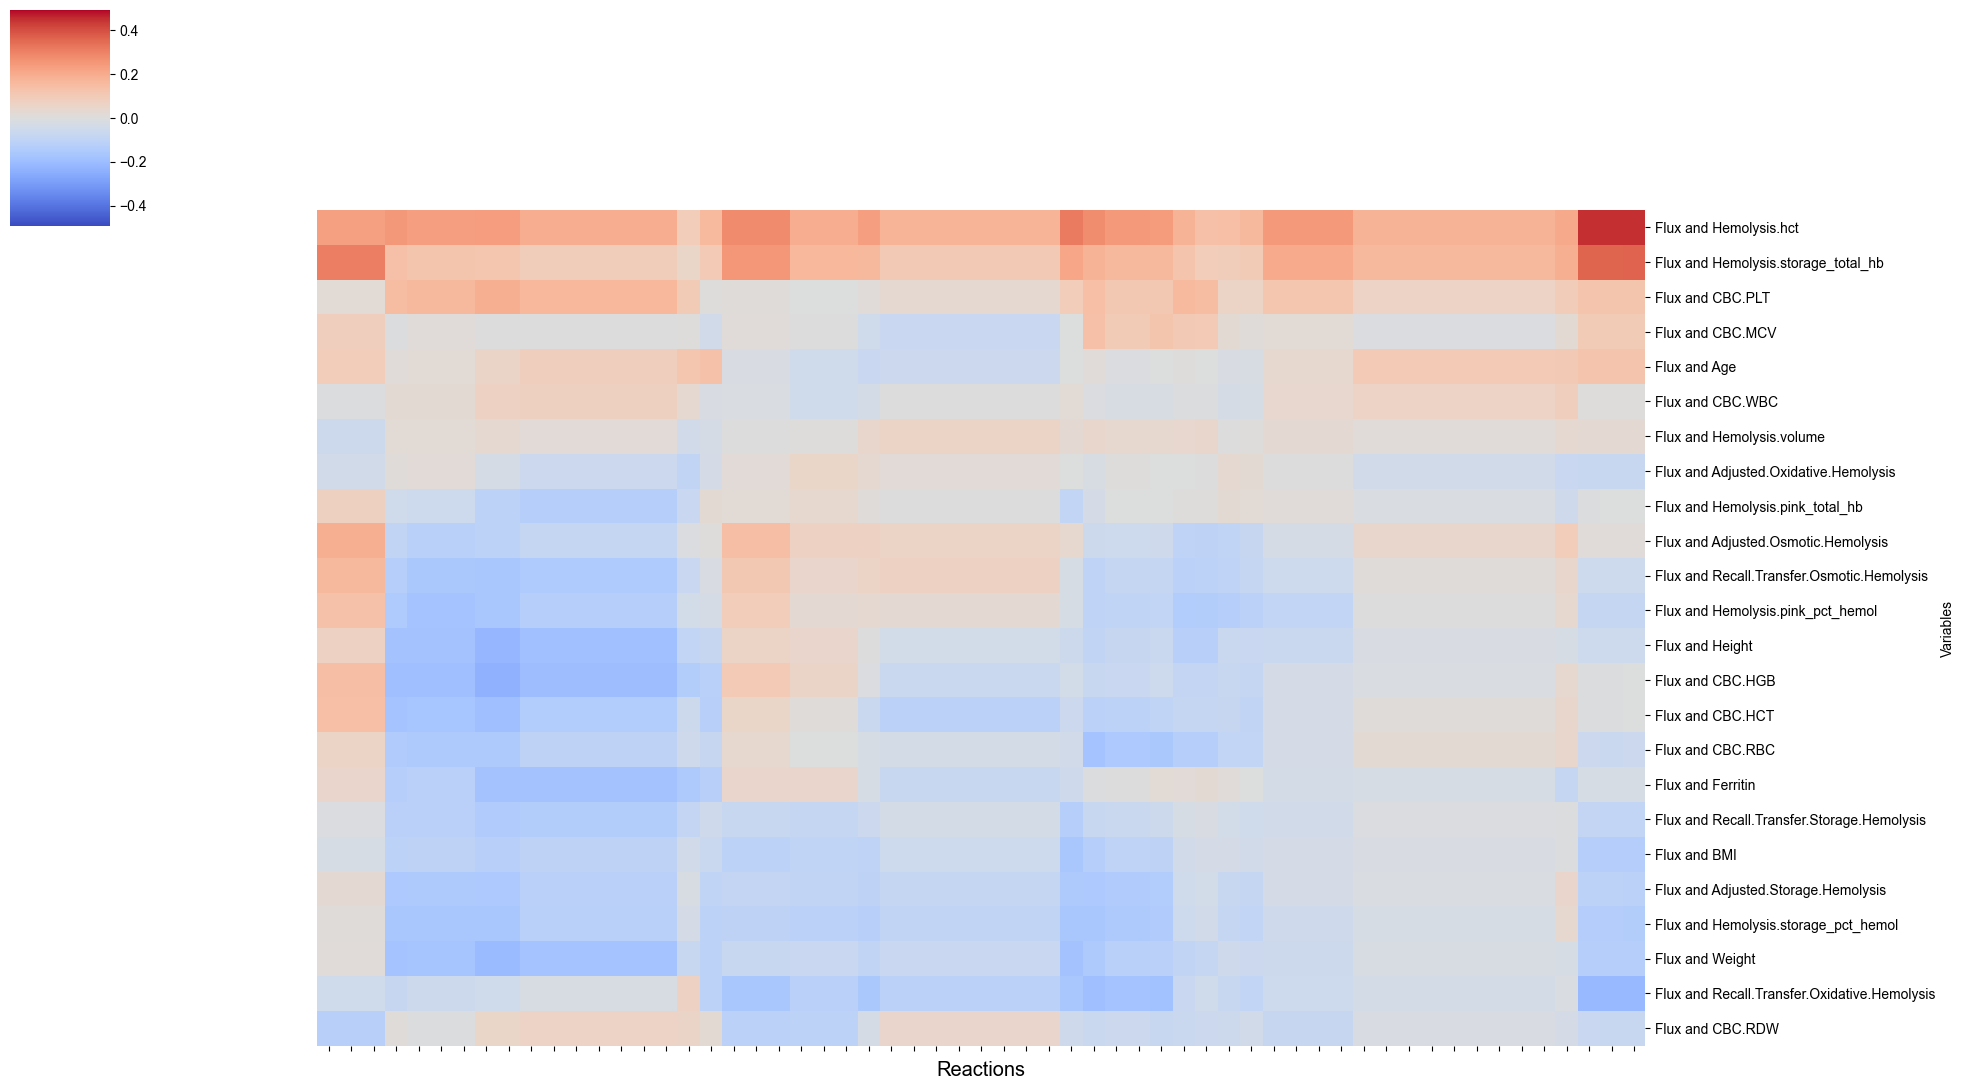

In [78]:
dtype = "Flux"
df_dtype = df_all_correlations.dropna().copy()
if "Flux and Expression" in df_dtype.columns:
    df_dtype = df_dtype.drop("Flux and Expression", level=0, axis=1)
df_dtype = df_dtype.loc[
    :, [x for x in df_dtype.columns if x[0].startswith(dtype) or x[0] in cat_cols]
]
df_dtype.to_csv(
    f"{dataset_path}/{pcmodel.id}_{dataset_name}_METADATA_{dtype.upper()}_CORRELATIONS.tsv",
    sep="\t",
    index=True,
)
df_dtype = df_dtype.loc[
    :, [x for x in df_dtype.columns if x[1] == "rho" or x[0] in cat_cols]
].droplevel(1, axis=1)
df_dtype

df_data = df_dtype.droplevel(1, axis=0)
df_data = df_data.loc[
    sorted(
        df_data.index,
        key=lambda x: (mapping_dict[model.reactions.get_by_id(x).subsystem], x),
    )
].T
df_data = df_data.loc[~df_data.index.isin(cat_cols)].astype(float)

# Cant exceed absolute value of 1
rho_lim = min(df_data.abs().max().max() * 1.1, 1)
fig = sns.clustermap(
    df_data,
    figsize=(20, 0.5 * len(df_data.index)),
    cmap="coolwarm",
    row_cluster=row_cluster,
    col_cluster=col_cluster,
    vmin=-rho_lim,
    vmax=rho_lim,
    row_linkage=linkage(
        df_data, method=row_method, metric=row_metric, optimal_ordering=optimal_ordering
    ),
    col_linkage=linkage(
        df_data.T,
        method=col_method,
        metric=col_metric,
        optimal_ordering=optimal_ordering,
    ),
    # col_colors=[category_colors[mapping_dict[model.reactions.get_by_id(x).subsystem]] for x in df_data.columns],
)
ax_heatmap = fig.ax_heatmap
ax_heatmap.set_xlabel("Reactions", fontsize="x-large")
ax_heatmap.xaxis.set_ticklabels([])
fig.ax_row_dendrogram.set_visible(False)
fig.ax_col_dendrogram.set_visible(False)
fig;

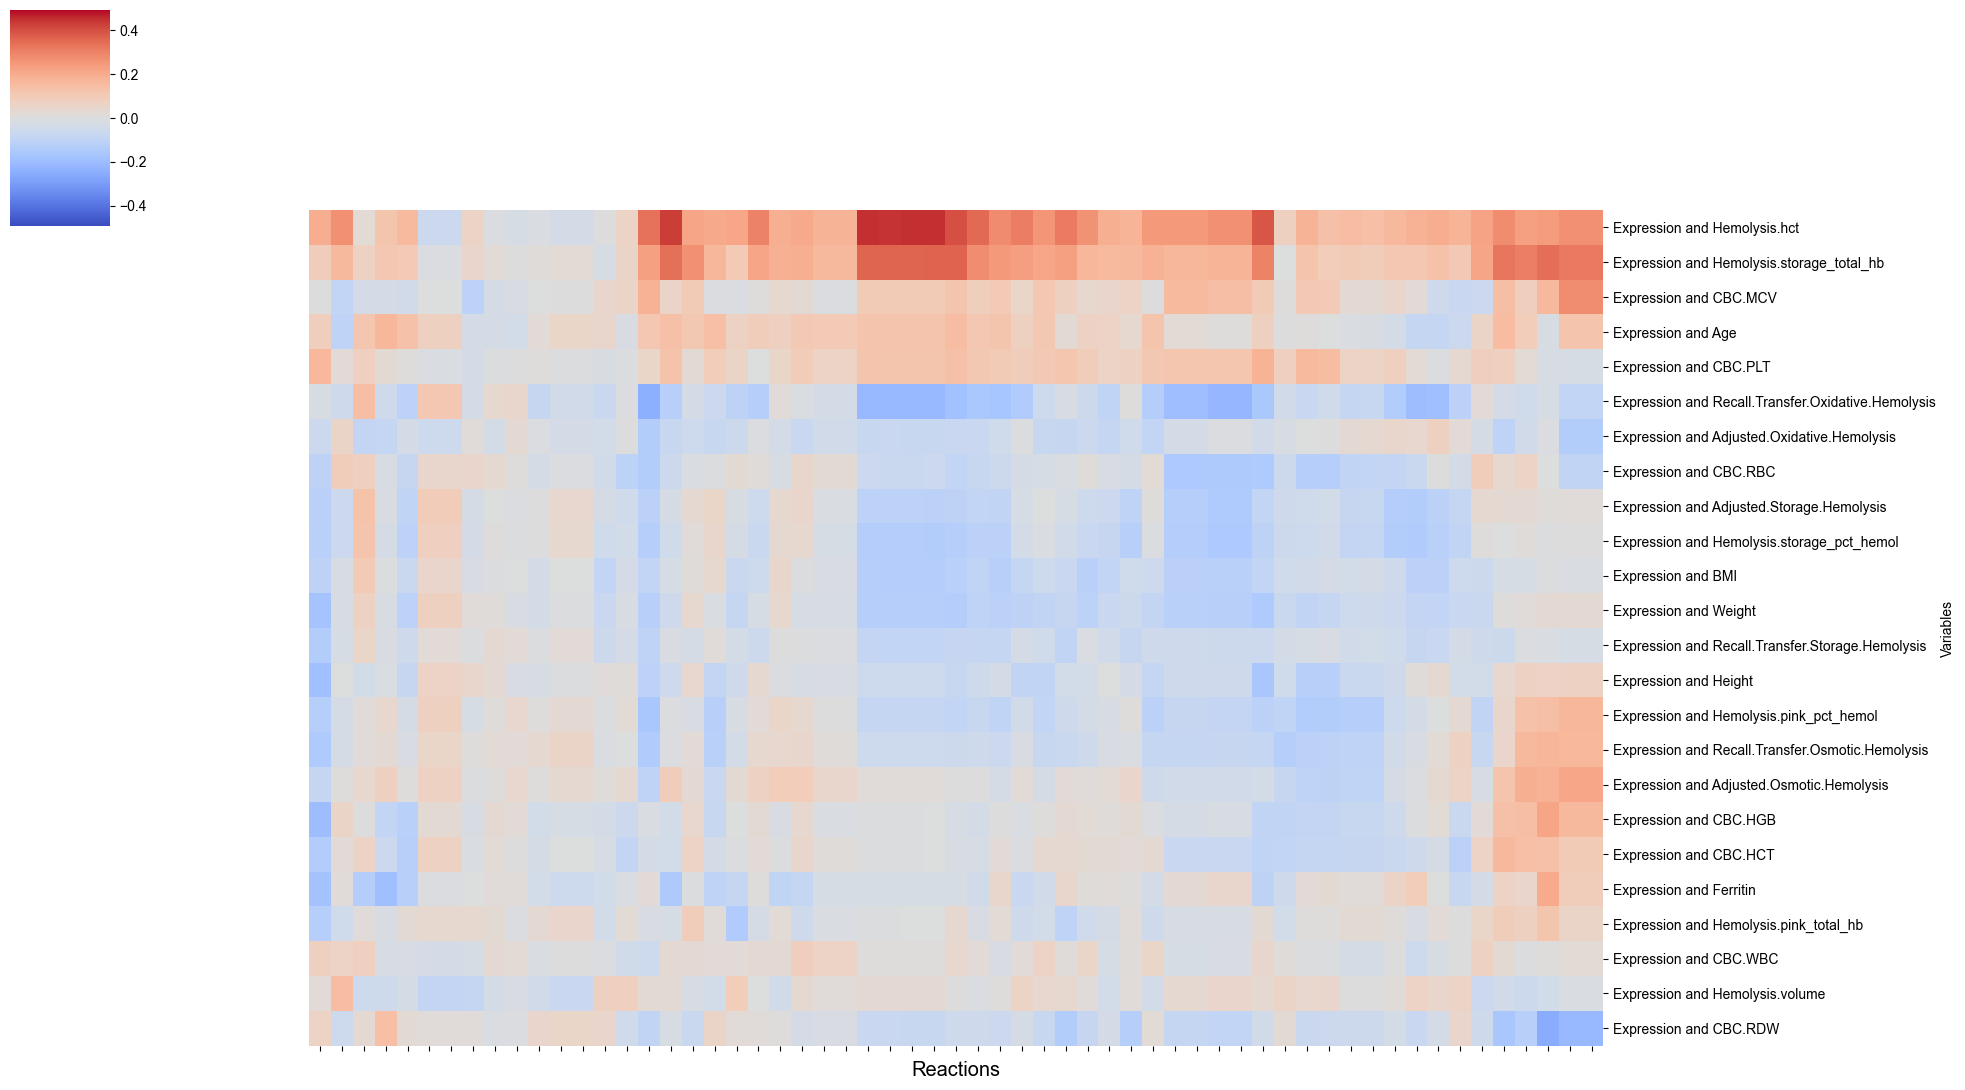

In [79]:
dtype = "Expr"
df_dtype = df_all_correlations.dropna().copy()
if "Flux and Expression" in df_dtype.columns:
    df_dtype = df_dtype.drop("Flux and Expression", level=0, axis=1)
df_dtype = df_dtype.loc[
    :, [x for x in df_dtype.columns if x[0].startswith(dtype) or x[0] in cat_cols]
]
df_dtype.to_csv(
    f"{dataset_path}/{pcmodel.id}_{dataset_name}_METADATA_{dtype.upper()}_CORRELATIONS.tsv",
    sep="\t",
    index=True,
)
df_dtype = df_dtype.loc[
    :, [x for x in df_dtype.columns if x[1] == "rho" or x[0] in cat_cols]
].droplevel(1, axis=1)
df_dtype

df_data = df_dtype.droplevel(1, axis=0)
df_data = df_data.loc[
    sorted(
        df_data.index,
        key=lambda x: (mapping_dict[model.reactions.get_by_id(x).subsystem], x),
    )
].T
df_data = df_data.loc[~df_data.index.isin(cat_cols)].astype(float)

# Cant exceed absolute value of 1
rho_lim = min(df_data.abs().max().max() * 1.1, 1)
fig = sns.clustermap(
    df_data,
    figsize=(20, 0.5 * len(df_data.index)),
    cmap="coolwarm",
    row_cluster=row_cluster,
    col_cluster=col_cluster,
    vmin=-rho_lim,
    vmax=rho_lim,
    row_linkage=linkage(
        df_data, method=row_method, metric=row_metric, optimal_ordering=optimal_ordering
    ),
    col_linkage=linkage(
        df_data.T,
        method=col_method,
        metric=col_metric,
        optimal_ordering=optimal_ordering,
    ),
    # col_colors=[category_colors[mapping_dict[model.reactions.get_by_id(x).subsystem]] for x in df_data.columns],
)
ax_heatmap = fig.ax_heatmap
ax_heatmap.set_xlabel("Reactions", fontsize="x-large")
ax_heatmap.xaxis.set_ticklabels([])
ax_heatmap.xaxis.set_tick_params(labelsize="x-large")
fig.ax_row_dendrogram.set_visible(False)
fig.ax_col_dendrogram.set_visible(False)

figures_path = root_path / "studies" / "rbc1" / "figures"
if save_figures:
    fig_filename = figures_path / f"Fig6_PanelB_{dtype}MetaDataCorr_{model.id}.{imagetype}"
    fig.savefig(
        fig_filename,
        transparent=transparent,
        format=imagetype,
    )
fig;

#### Visualize correlations with metadata

In [80]:
# Consistent plot dimensions and values
pvalue_tol = 1e-320
scatter_inch = 5  # Length x width of scatter plot
hist_inch = 1  # Length or width of histogram addition
hist_pad = 0.4  # Space between scatter and histogram
cmap = "viridis"
edgecolor = "black"
edgewidth = 0.5
grid = False
zorder = 2
histx = True
histy = True

##### Age

Variables                                                   Flux and Age  \
Spearman correlation                                                 rho   
reaction genes                                                             
AMPDA    AMPD3                                                  0.133314   
CA2t     CACNA1A;GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;TM...     0.125756   
NAt      GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;SCN4A;SCN9...     0.125711   
Kt1      GRIA1;KCNAB2;KCNK5;KCNN4;P2RX1;P2RX2;P2RX7;PANX...     0.123074   
PYRt2    BSG;EMB;SLC16A1;SLC16A7                                0.116452   
PGI      GPI                                                    0.104104   
NTDAMP   NT5C2                                                  0.101579   
NTDIMP   NT5C2                                                  0.101579   
ADNK1    ADK                                                    0.101579   
HXPRT    HPRT1                                                  0.101579   

Variables  

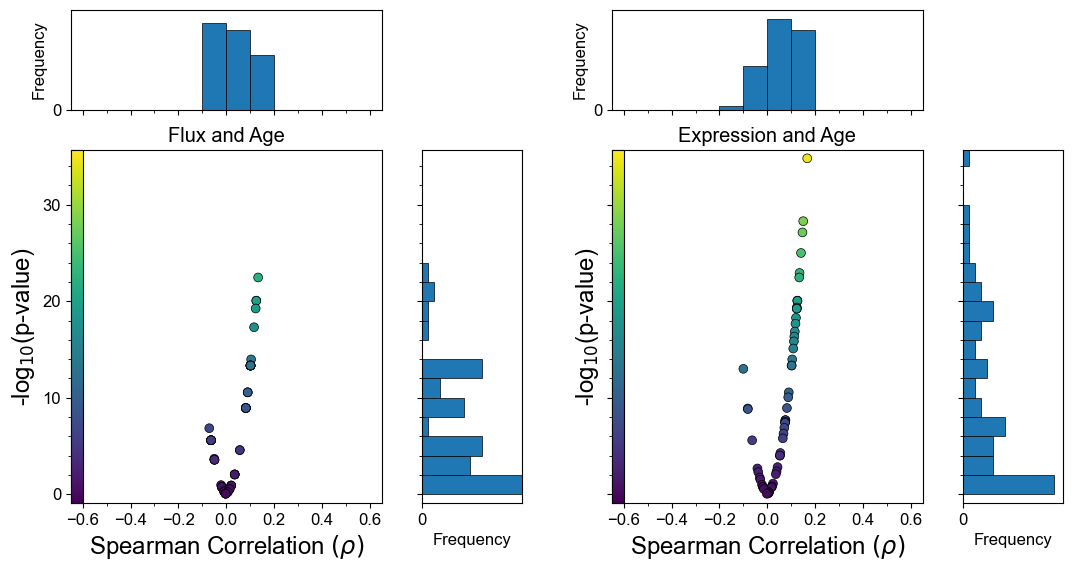

In [81]:
metadata_col = "Age"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)

print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### BMI

Variables                                                   Flux and BMI  \
Spearman correlation                                                 rho   
reaction genes                                                             
DPGM     BPGM;PGAM1                                            -0.162180   
CA2t     CACNA1A;GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;TM...    -0.131132   
NAt      GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;SCN4A;SCN9...    -0.131050   
INSt     SLC29A1                                               -0.129105   
Kt1      GRIA1;KCNAB2;KCNK5;KCNN4;P2RX1;P2RX2;P2RX7;PANX...    -0.128756   
HEX1     HK1;HK3                                               -0.124002   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4                   -0.124002   
RPI      RPIA                                                  -0.110976   
GAPD     GAPDH;GAPDHS                                          -0.109190   
LDH_L    LDHA;LDHB                                             -0.109190   

Variables  

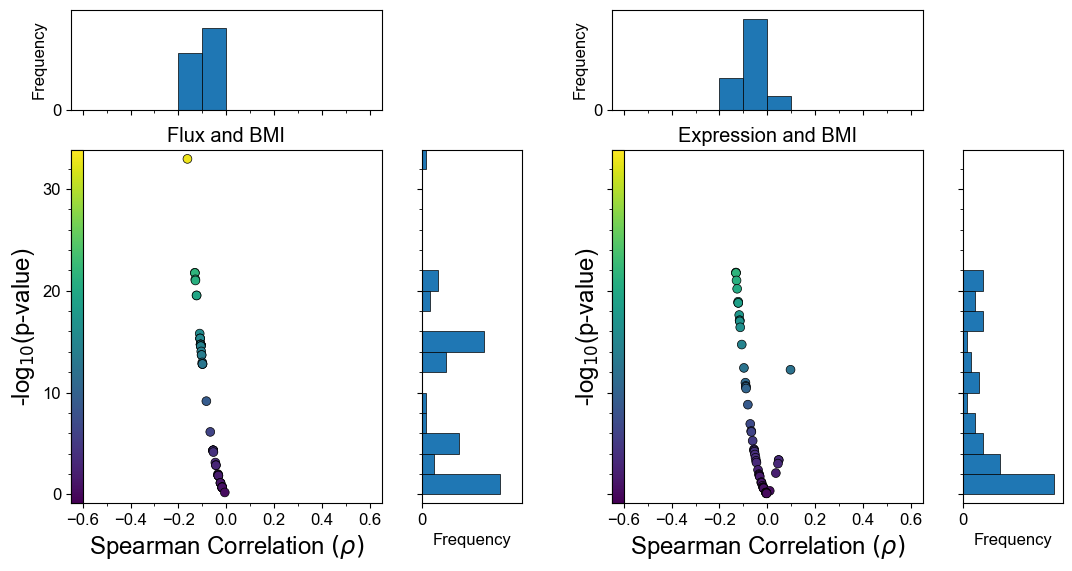

In [82]:
metadata_col = "BMI"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = round(
        max(df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max())
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Weight

Variables                                          Flux and Weight  \
Spearman correlation                                           rho   
reaction genes                                                       
HEX1     HK1;HK3                                         -0.207674   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4             -0.207674   
DPGM     BPGM;PGAM1                                      -0.180736   
PYK      PKLR;PKM                                        -0.180136   
ENO      ENO1;ENO2;ENO3                                  -0.180136   
CAATPS1  ATP2B1;ATP2B4                                   -0.180136   
PGK      PGK1;PGK2                                       -0.180136   
NaKt     ATP1A1;ATP1A3;ATP1A4;ATP1B1;ATP1B2;ATP1B3       -0.180136   
DPGase   BPGM                                            -0.180136   
PGM      BPGM;PGAM1                                      -0.180136   

Variables                                                         
Spearman correlation  

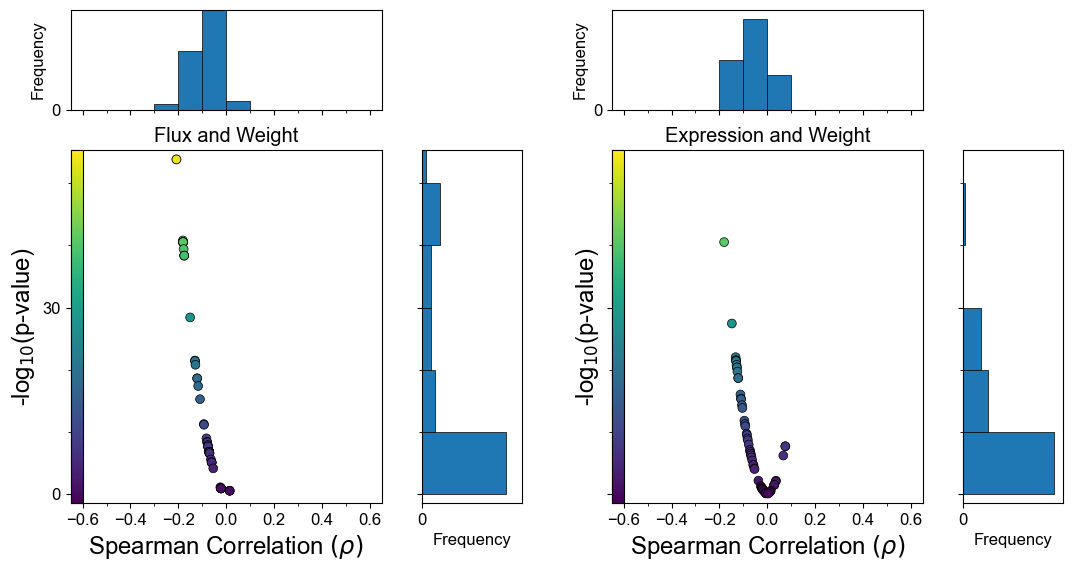

In [83]:
metadata_col = "Weight"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=30,
    ytick_minor=10,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = round(
        max(df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max())
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Height

Variables                                          Flux and Height  \
Spearman correlation                                           rho   
reaction genes                                                       
HEX1     HK1;HK3                                         -0.221130   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4             -0.221130   
PYK      PKLR;PKM                                        -0.188725   
ENO      ENO1;ENO2;ENO3                                  -0.188725   
CAATPS1  ATP2B1;ATP2B4                                   -0.188725   
PGK      PGK1;PGK2                                       -0.188725   
NaKt     ATP1A1;ATP1A3;ATP1A4;ATP1B1;ATP1B2;ATP1B3       -0.188725   
DPGase   BPGM                                            -0.188725   
PGM      BPGM;PGAM1                                      -0.188725   
PPM      PGM2                                            -0.184089   

Variables                                                         
Spearman correlation  

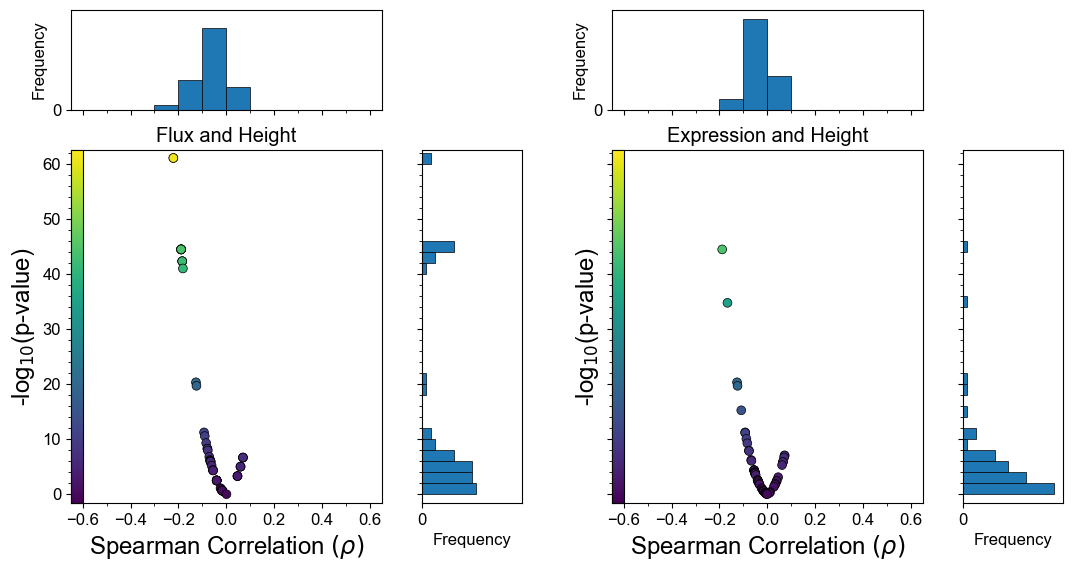

In [84]:
metadata_col = "Height"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = round(
        max(df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max())
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Hemolysis.volume

Variables                  Flux and Hemolysis.volume          
Spearman correlation                             rho    pvalue
reaction    genes                                             
G6PDH2      G6PD                            0.061220  0.000006
PGL         PGLS                            0.061220  0.000006
GTHP        GPX1;GPX4                       0.061220  0.000006
FE3RD       STEAP3                          0.061220  0.000006
GND         PGD                             0.061220  0.000006
GTHOy       GSR                             0.061220  0.000006
BILIREDy    BLVRA;BLVRB                     0.061220  0.000006
BILRUBABCte ABCC4                           0.061220  0.000006
PFK         PFKL;PFKM;PFKP                 -0.060906  0.000006
TPI         TPI1                           -0.060906  0.000006

Variables                                                     Expression and Hemolysis.volume  \
Spearman correlation                                                               

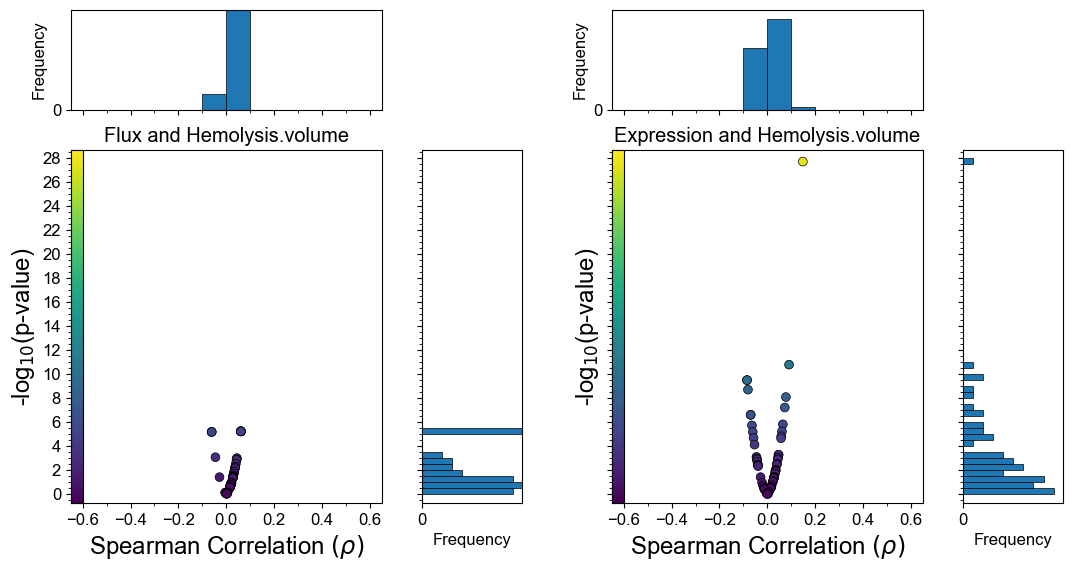

In [85]:
metadata_col = "Hemolysis.volume"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=2,
    ytick_minor=0.5,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = round(
        max(df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max())
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Hemolysis.hct

Variables                                                   Flux and Hemolysis.hct  \
Spearman correlation                                                           rho   
reaction genes                                                                       
NAt      GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;SCN4A;SCN9...               0.447345   
CA2t     CACNA1A;GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;TM...               0.446367   
Kt1      GRIA1;KCNAB2;KCNK5;KCNN4;P2RX1;P2RX2;P2RX7;PANX...               0.445954   
DPGM     BPGM;PGAM1                                                       0.313751   
GAPD     GAPDH;GAPDHS                                                     0.277084   
LDH_L    LDHA;LDHB                                                        0.277084   
L_LACt2  BSG;EMB;SLC16A1;SLC16A7                                          0.277084   
INSt     SLC29A1                                                          0.274331   
RPI      RPIA                                         

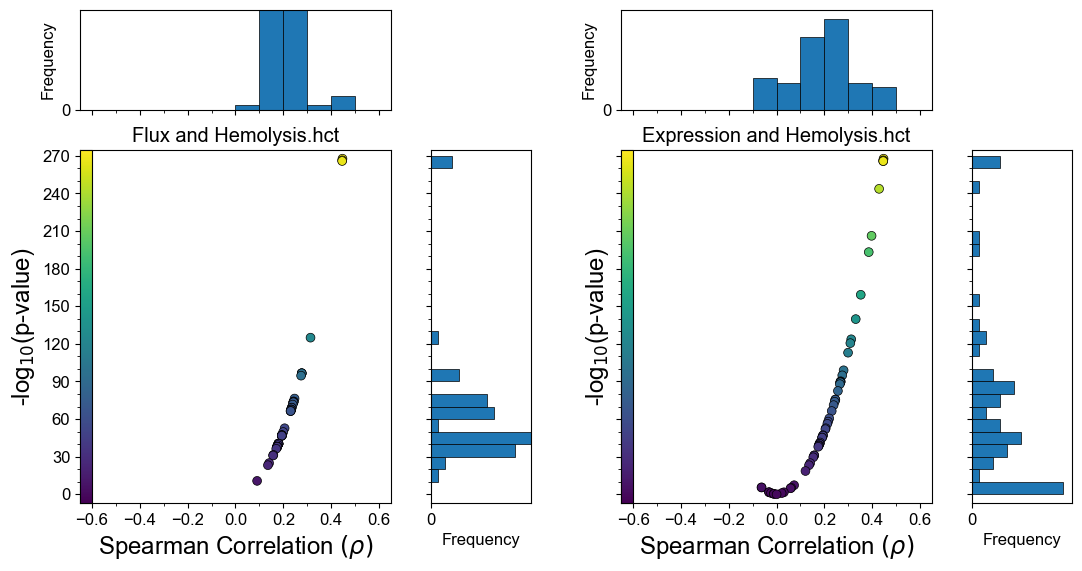

In [86]:
metadata_col = "Hemolysis.hct"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=30,
    ytick_minor=10,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = round(
        max(df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max())
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)

axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Hemolysis.storage_total_hb

Variables                                                   Flux and Hemolysis.storage_total_hb  \
Spearman correlation                                                                        rho   
reaction genes                                                                                    
NAt      GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;SCN4A;SCN9...                            0.361591   
CA2t     CACNA1A;GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;TM...                            0.359332   
Kt1      GRIA1;KCNAB2;KCNK5;KCNN4;P2RX1;P2RX2;P2RX7;PANX...                            0.358407   
PFK      PFKL;PFKM;PFKP                                                                0.306161   
TPI      TPI1                                                                          0.306161   
FBA      ALDOA;ALDOB;ALDOC                                                             0.306161   
GAPD     GAPDH;GAPDHS                                                                  0.250865   
LDH_L    L

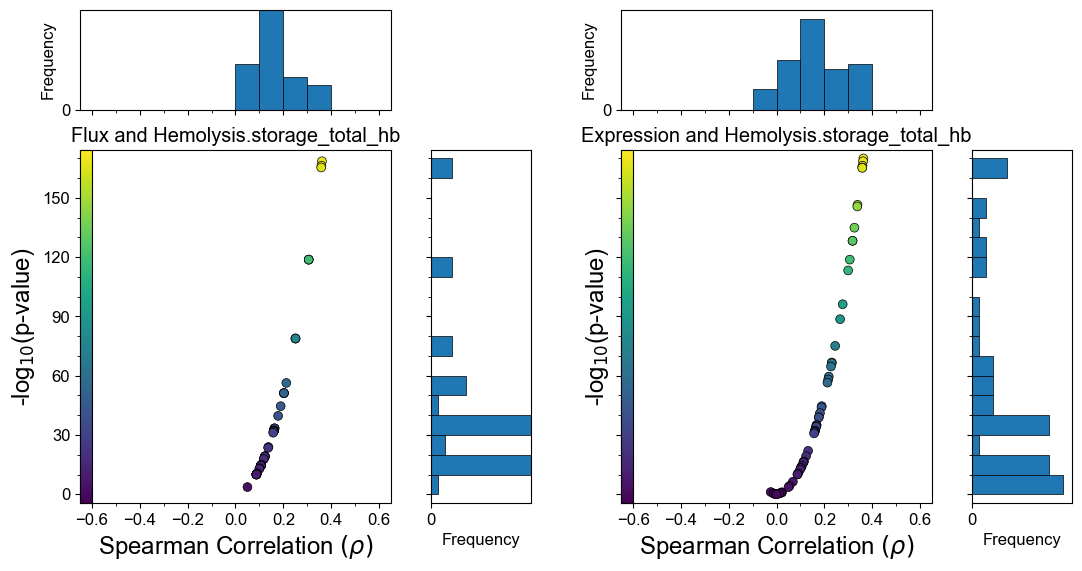

In [87]:
metadata_col = "Hemolysis.storage_total_hb"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=30,
    ytick_minor=10,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = round(
        max(df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max())
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Hemolysis.storage_pct_hemol

Variables                                    Flux and Hemolysis.storage_pct_hemol  \
Spearman correlation                                                          rho   
reaction genes                                                                      
DPGM     BPGM;PGAM1                                                     -0.165817   
RPI      RPIA                                                           -0.164896   
HEX1     HK1;HK3                                                        -0.162587   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4                            -0.162587   
PPM      PGM2                                                           -0.161691   
HYXNt    SLC29A1;SLC43A3                                                -0.161691   
PUNP5    PNP                                                            -0.161691   
INSt     SLC29A1                                                        -0.161589   
NH4t     AQP1;AQP3;RHAG;RHCE;RHD                                 

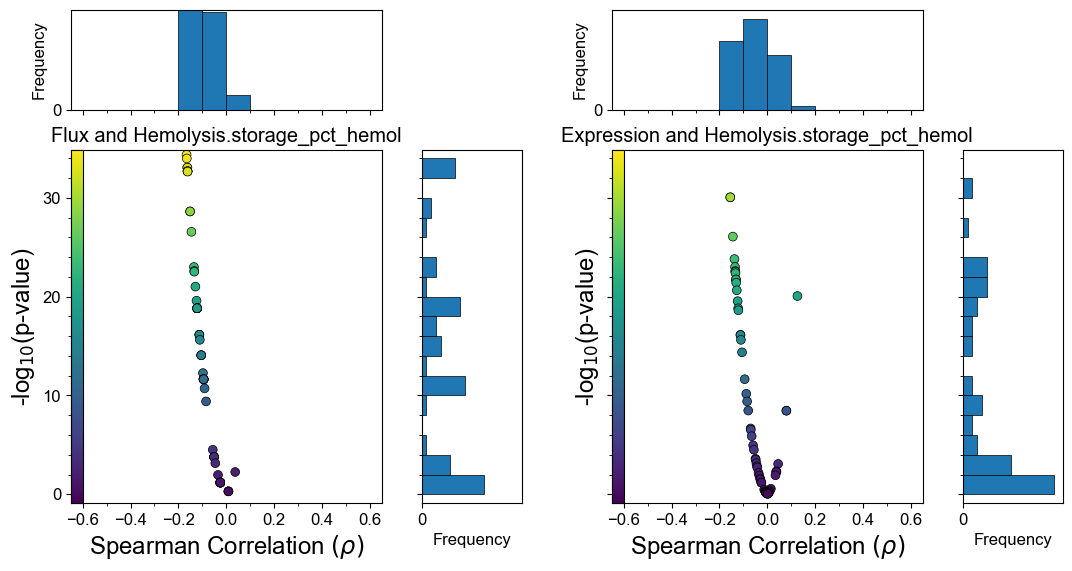

In [88]:
metadata_col = "Hemolysis.storage_pct_hemol"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = round(
        max(df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max())
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Hemolysis.pink_total_hb

Variables                                          Flux and Hemolysis.pink_total_hb  \
Spearman correlation                                                            rho   
reaction genes                                                                        
PYK      PKLR;PKM                                                         -0.128867   
ENO      ENO1;ENO2;ENO3                                                   -0.128867   
CAATPS1  ATP2B1;ATP2B4                                                    -0.128867   
PGK      PGK1;PGK2                                                        -0.128867   
NaKt     ATP1A1;ATP1A3;ATP1A4;ATP1B1;ATP1B2;ATP1B3                        -0.128867   
DPGase   BPGM                                                             -0.128867   
PGM      BPGM;PGAM1                                                       -0.128867   
HEX1     HK1;HK3                                                          -0.109806   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A

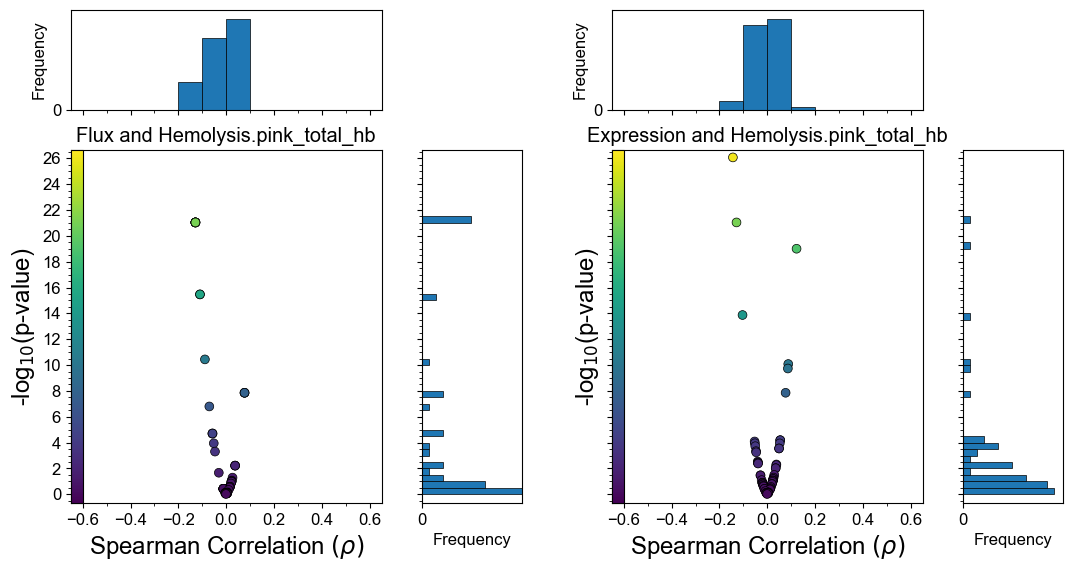

In [89]:
metadata_col = "Hemolysis.pink_total_hb"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=2,
    ytick_minor=0.5,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = round(
        max(df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max())
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Hemolysis.pink_pct_hemol

Variables                                    Flux and Hemolysis.pink_pct_hemol  \
Spearman correlation                                                       rho   
reaction genes                                                                   
PPM      PGM2                                                        -0.176882   
HYXNt    SLC29A1;SLC43A3                                             -0.176882   
PUNP5    PNP                                                         -0.176882   
HEX1     HK1;HK3                                                     -0.167252   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4                         -0.167252   
RPI      RPIA                                                        -0.149152   
H2Ot     AQP1;AQP3                                                   -0.141929   
O2t      AQP1                                                        -0.137801   
PFK      PFKL;PFKM;PFKP                                               0.132432   
TPI      TPI1   

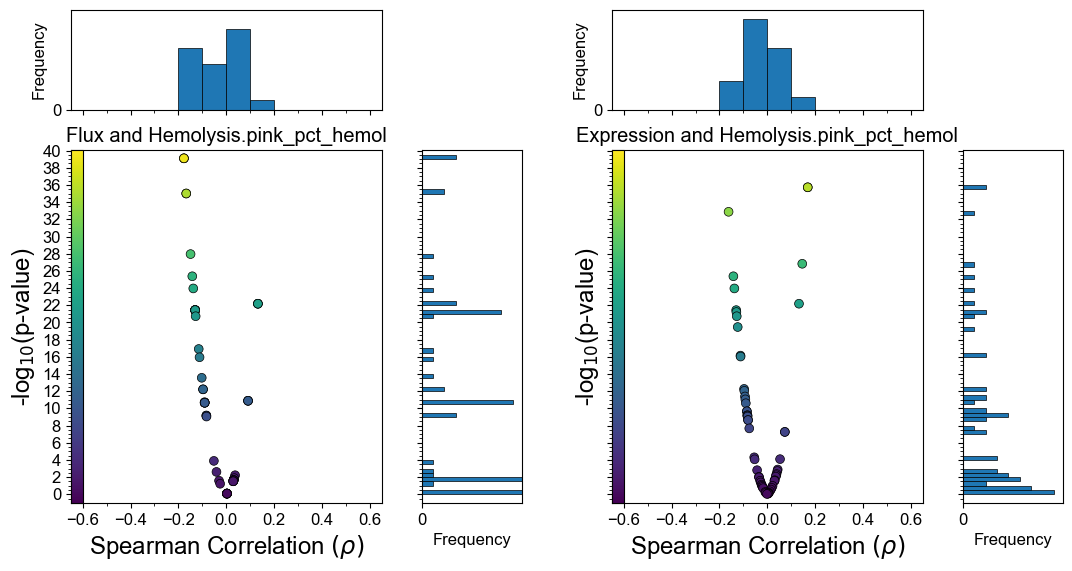

In [90]:
metadata_col = "Hemolysis.pink_pct_hemol"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=2,
    ytick_minor=0.5,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Recall.Transfer.Storage.Hemolysis

Variables                                          Flux and Recall.Transfer.Storage.Hemolysis  \
Spearman correlation                                                                      rho   
reaction genes                                                                                  
HEX1     HK1;HK3                                                                    -0.142722   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4                                        -0.142722   
PYK      PKLR;PKM                                                                   -0.135436   
ENO      ENO1;ENO2;ENO3                                                             -0.135436   
CAATPS1  ATP2B1;ATP2B4                                                              -0.135436   
PGK      PGK1;PGK2                                                                  -0.135436   
NaKt     ATP1A1;ATP1A3;ATP1A4;ATP1B1;ATP1B2;ATP1B3                                  -0.135436   
DPGase   BPGM                 

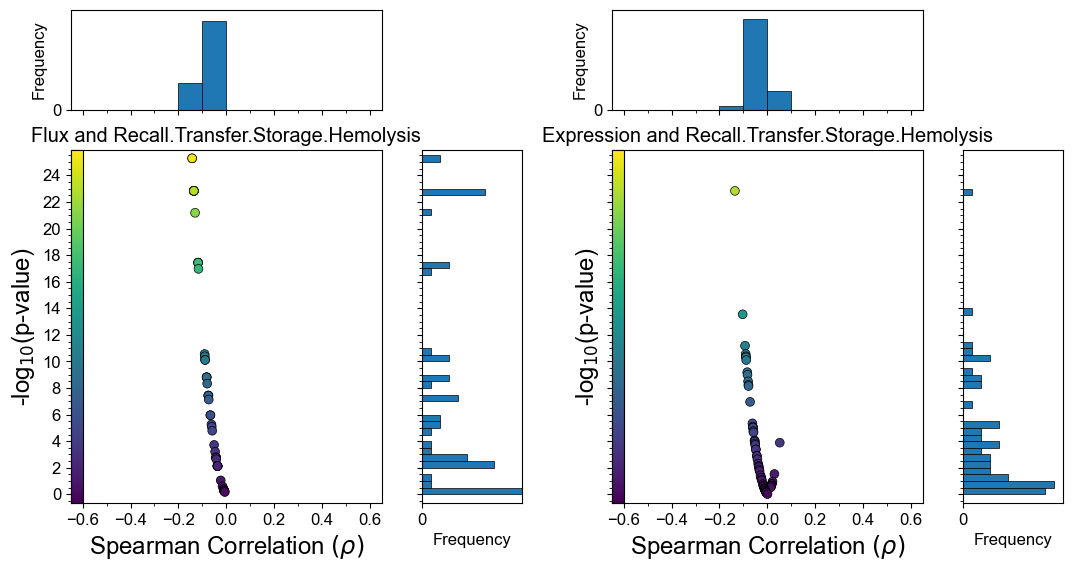

In [91]:
metadata_col = "Recall.Transfer.Storage.Hemolysis"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=2,
    ytick_minor=0.5,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Recall.Transfer.Osmotic.Hemolysis

Variables                                    Flux and Recall.Transfer.Osmotic.Hemolysis  \
Spearman correlation                                                                rho   
reaction genes                                                                            
HEX1     HK1;HK3                                                              -0.166858   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4                                  -0.166858   
PPM      PGM2                                                                 -0.159994   
HYXNt    SLC29A1;SLC43A3                                                      -0.159994   
PUNP5    PNP                                                                  -0.159994   
PFK      PFKL;PFKM;PFKP                                                        0.159570   
TPI      TPI1                                                                  0.159570   
FBA      ALDOA;ALDOB;ALDOC                                                     0.159570   

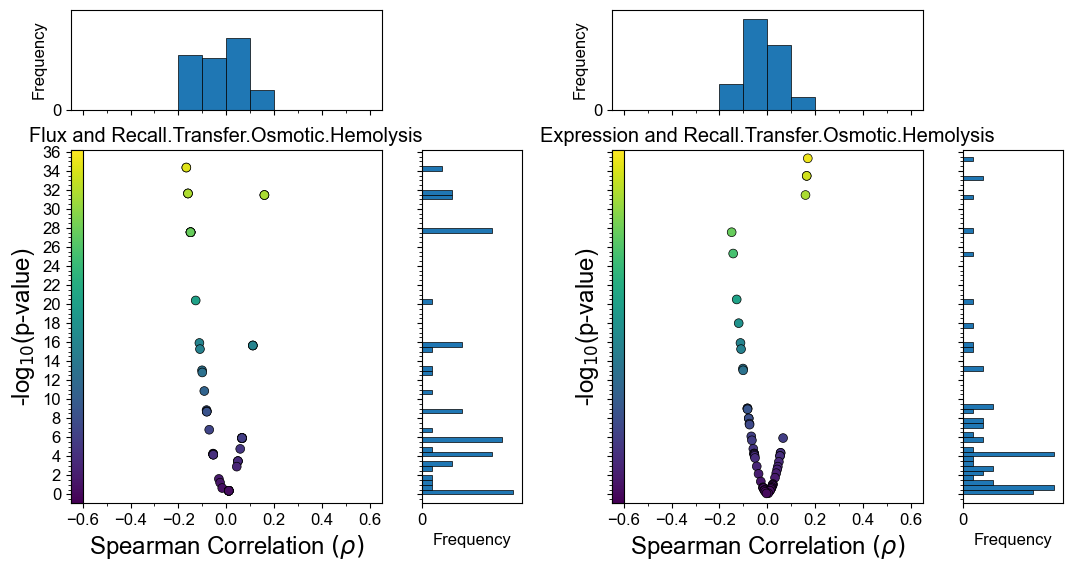

In [92]:
metadata_col = "Recall.Transfer.Osmotic.Hemolysis"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=2,
    ytick_minor=0.5,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Recall.Transfer.Oxidative.Hemolysis

Variables                                                   Flux and Recall.Transfer.Oxidative.Hemolysis  \
Spearman correlation                                                                                 rho   
reaction genes                                                                                             
Kt1      GRIA1;KCNAB2;KCNK5;KCNN4;P2RX1;P2RX2;P2RX7;PANX...                                    -0.212272   
CA2t     CACNA1A;GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;TM...                                    -0.211865   
NAt      GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;SCN4A;SCN9...                                    -0.211592   
INSt     SLC29A1                                                                               -0.193643   
ADNt     SLC29A1                                                                               -0.185735   
NH4t     AQP1;AQP3;RHAG;RHCE;RHD                                                               -0.178575   
ADA      ADA                

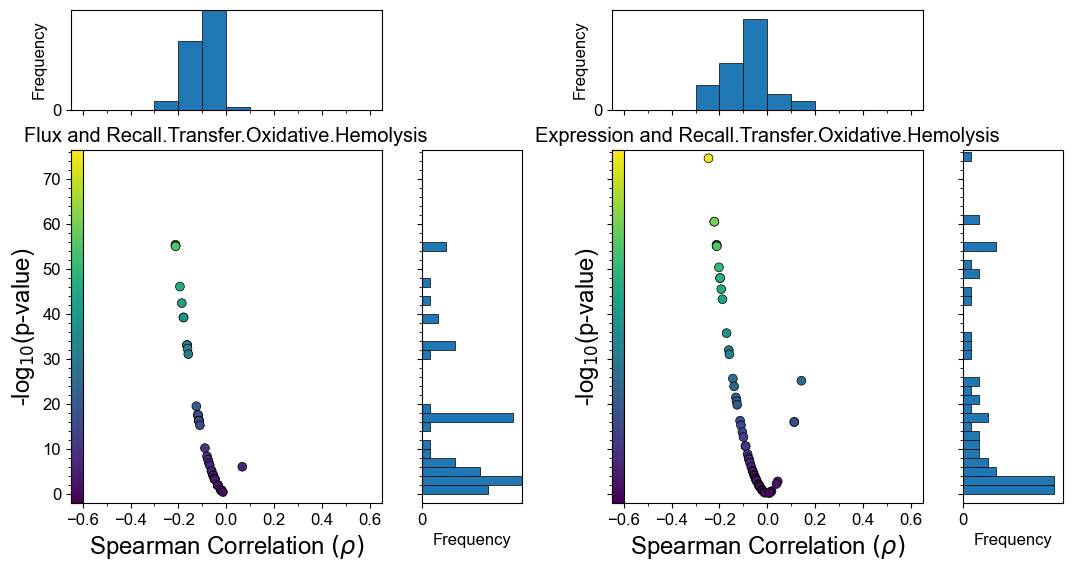

In [93]:
metadata_col = "Recall.Transfer.Oxidative.Hemolysis"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Adjusted.Storage.Hemolysis

Variables                                    Flux and Adjusted.Storage.Hemolysis  \
Spearman correlation                                                         rho   
reaction genes                                                                     
INSt     SLC29A1                                                       -0.156176   
HEX1     HK1;HK3                                                       -0.155788   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4                           -0.155788   
RPI      RPIA                                                          -0.153880   
PPM      PGM2                                                          -0.152482   
HYXNt    SLC29A1;SLC43A3                                               -0.152482   
PUNP5    PNP                                                           -0.152482   
DPGM     BPGM;PGAM1                                                    -0.150238   
NH4t     AQP1;AQP3;RHAG;RHCE;RHD                                       -0.14

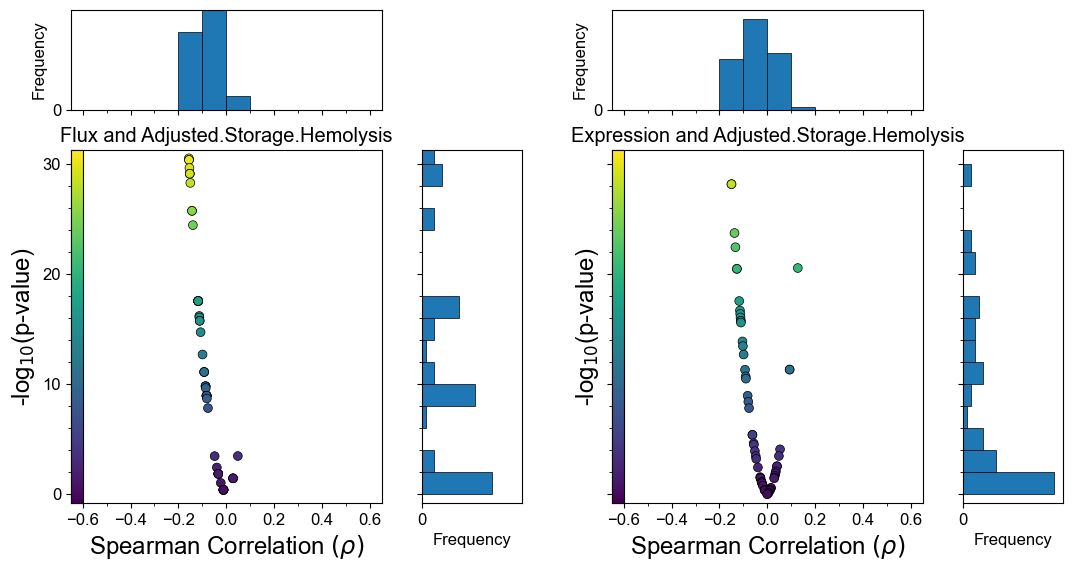

In [94]:
metadata_col = "Adjusted.Storage.Hemolysis"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Adjusted.Osmotic.Hemolysis

Variables                        Flux and Adjusted.Osmotic.Hemolysis  \
Spearman correlation                                             rho   
reaction genes                                                         
PFK      PFKL;PFKM;PFKP                                     0.190131   
TPI      TPI1                                               0.190131   
FBA      ALDOA;ALDOB;ALDOC                                  0.190131   
GAPD     GAPDH;GAPDHS                                       0.144668   
LDH_L    LDHA;LDHB                                          0.144668   
L_LACt2  BSG;EMB;SLC16A1;SLC16A7                            0.144668   
PPM      PGM2                                              -0.122918   
HYXNt    SLC29A1;SLC43A3                                   -0.122918   
PUNP5    PNP                                               -0.122918   
HEX1     HK1;HK3                                           -0.110133   

Variables                                       
Spearman corre

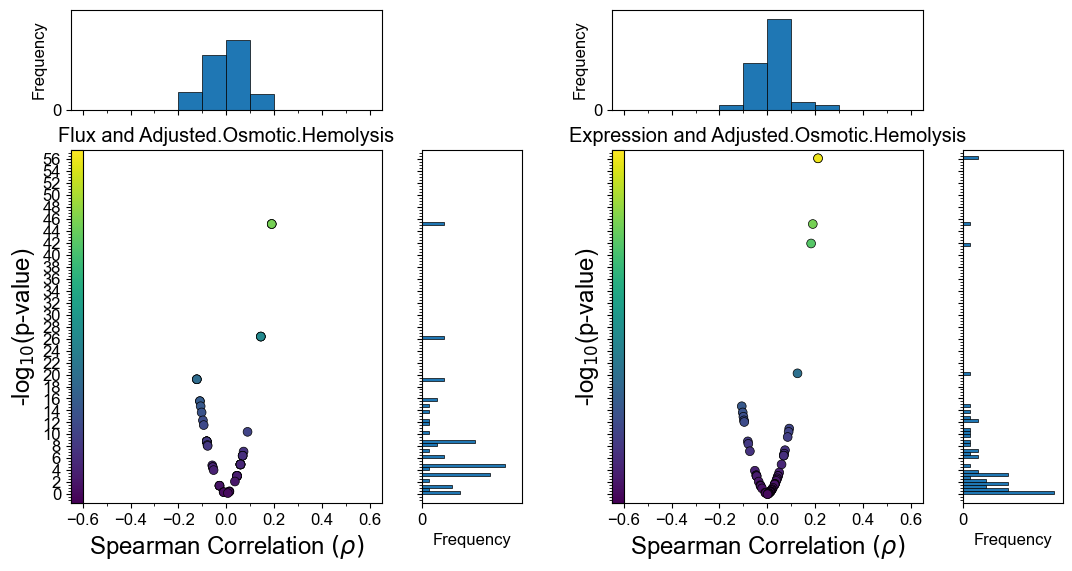

In [95]:
metadata_col = "Adjusted.Osmotic.Hemolysis"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=2,
    ytick_minor=0.5,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Adjusted.Oxidative.Hemolysis

Variables                                                   Flux and Adjusted.Oxidative.Hemolysis  \
Spearman correlation                                                                          rho   
reaction genes                                                                                      
PYRt2    BSG;EMB;SLC16A1;SLC16A7                                                        -0.094475   
NAt      GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;SCN4A;SCN9...                             -0.074113   
Kt1      GRIA1;KCNAB2;KCNK5;KCNN4;P2RX1;P2RX2;P2RX7;PANX...                             -0.073796   
CA2t     CACNA1A;GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;TM...                             -0.073265   
PGI      GPI                                                                            -0.072838   
PYK      PKLR;PKM                                                                       -0.065063   
ENO      ENO1;ENO2;ENO3                                                                 -0.

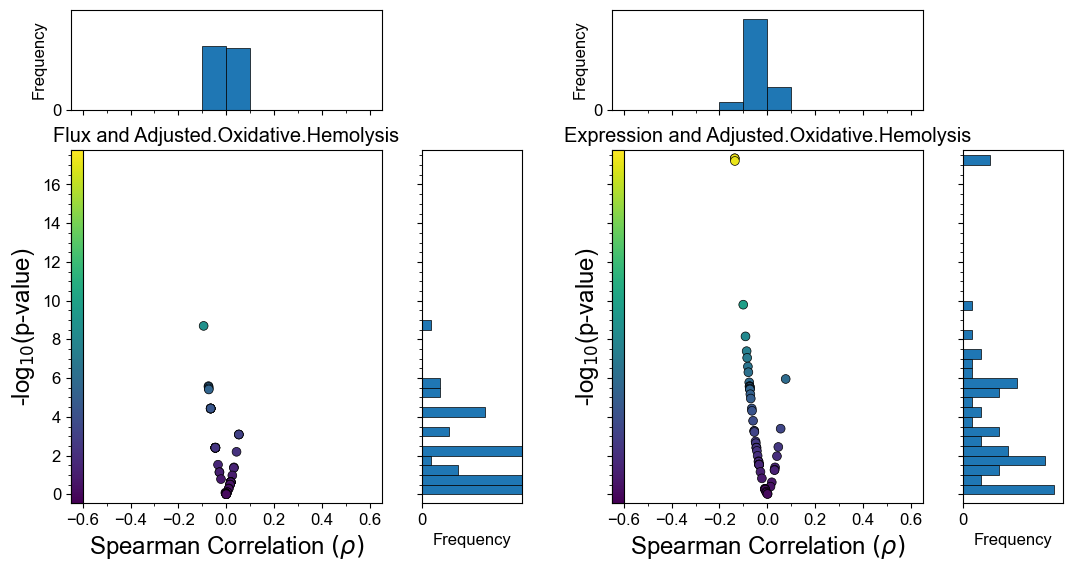

In [96]:
metadata_col = "Adjusted.Oxidative.Hemolysis"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=2,
    ytick_minor=0.5,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### CBC.WBC

Variables                                          Flux and CBC.WBC  \
Spearman correlation                                            rho   
reaction genes                                                        
PGI      GPI                                               0.082400   
PYK      PKLR;PKM                                          0.074188   
ENO      ENO1;ENO2;ENO3                                    0.074188   
CAATPS1  ATP2B1;ATP2B4                                     0.074188   
PGK      PGK1;PGK2                                         0.074188   
NaKt     ATP1A1;ATP1A3;ATP1A4;ATP1B1;ATP1B2;ATP1B3         0.074188   
DPGase   BPGM                                              0.074188   
PGM      BPGM;PGAM1                                        0.074188   
HEX1     HK1;HK3                                           0.069991   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4               0.069991   

Variables                                                         
Spearman 

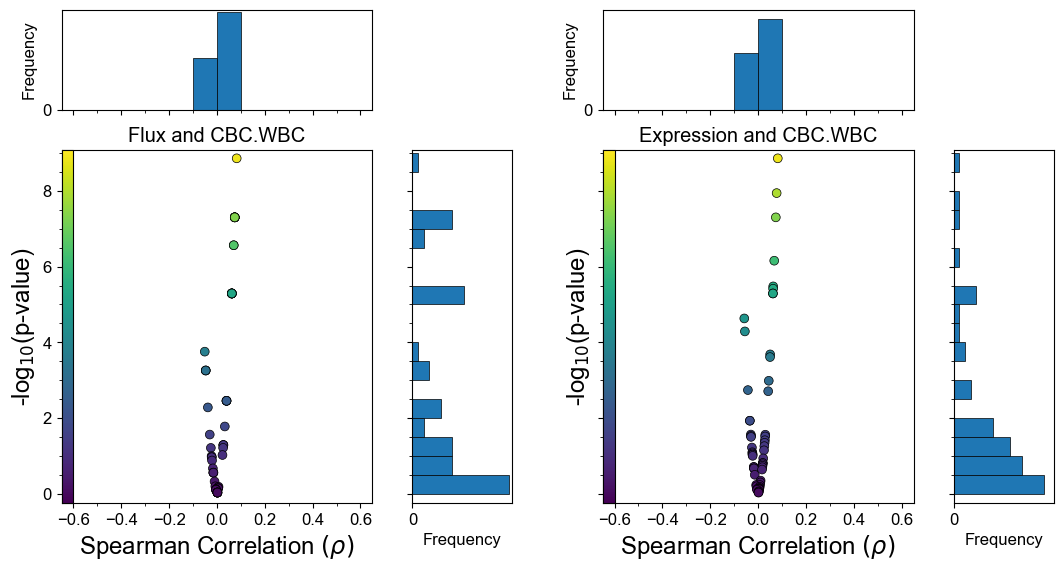

In [97]:
metadata_col = "CBC.WBC"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=2,
    ytick_minor=0.5,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### CBC.RBC

Variables                                    Flux and CBC.RBC              
Spearman correlation                                      rho        pvalue
reaction genes                                                             
INSt     SLC29A1                                    -0.178930  5.846348e-40
ADNt     SLC29A1                                    -0.158633  1.143611e-31
NH4t     AQP1;AQP3;RHAG;RHCE;RHD                    -0.154065  6.046476e-30
ADA      ADA                                        -0.154065  6.046476e-30
HEX1     HK1;HK3                                    -0.152291  2.734075e-29
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4        -0.152291  2.734075e-29
PPM      PGM2                                       -0.151230  6.676484e-29
HYXNt    SLC29A1;SLC43A3                            -0.151230  6.676484e-29
PUNP5    PNP                                        -0.151230  6.676484e-29
RPI      RPIA                                       -0.143429  3.910285e-26

Variables  

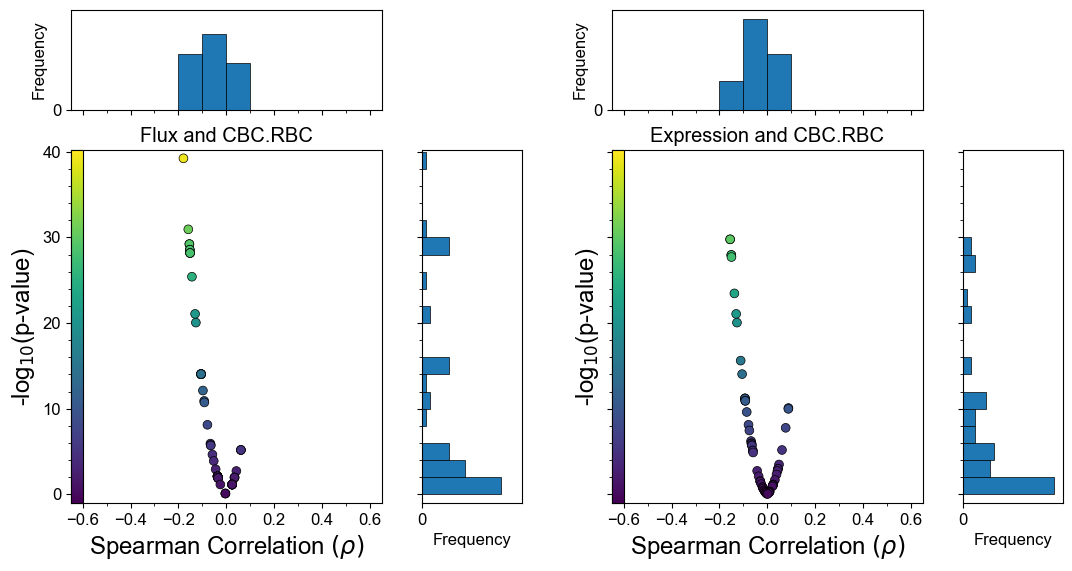

In [98]:
metadata_col = "CBC.RBC"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### CBC.HGB

Variables                                          Flux and CBC.HGB  \
Spearman correlation                                            rho   
reaction genes                                                        
HEX1     HK1;HK3                                          -0.237236   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4              -0.237236   
PYK      PKLR;PKM                                         -0.201680   
ENO      ENO1;ENO2;ENO3                                   -0.201680   
CAATPS1  ATP2B1;ATP2B4                                    -0.201680   
PGK      PGK1;PGK2                                        -0.201680   
NaKt     ATP1A1;ATP1A3;ATP1A4;ATP1B1;ATP1B2;ATP1B3        -0.201680   
DPGase   BPGM                                             -0.201680   
PGM      BPGM;PGAM1                                       -0.201680   
PPM      PGM2                                             -0.195658   

Variables                                                         
Spearman 

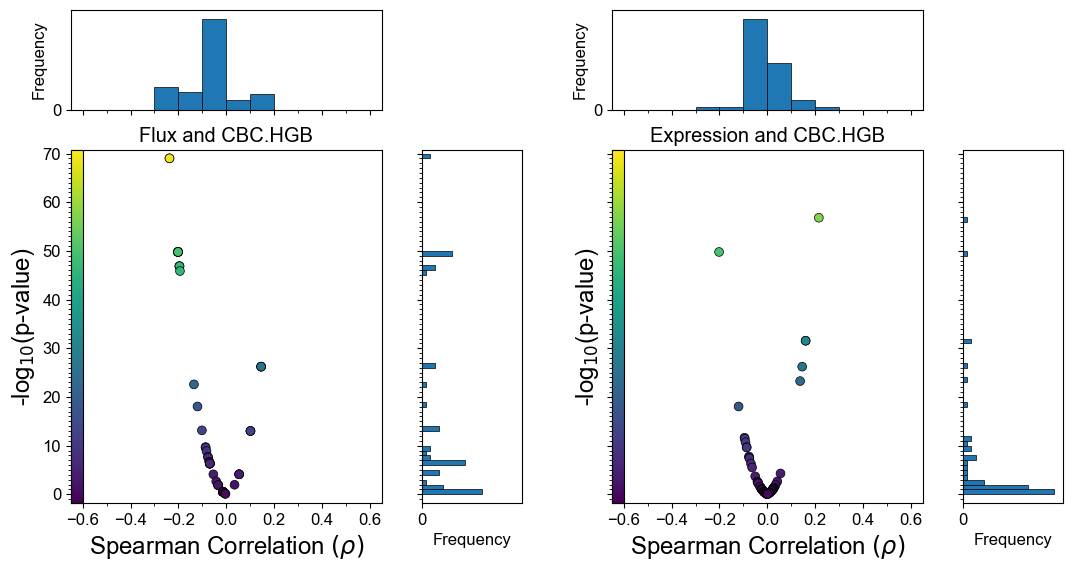

In [99]:
metadata_col = "CBC.HGB"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=800,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=1,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=800,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### CBC.HCT

Variables                                    Flux and CBC.HCT              
Spearman correlation                                      rho        pvalue
reaction genes                                                             
HEX1     HK1;HK3                                    -0.192531  4.186668e-46
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4        -0.192531  4.186668e-46
RPI      RPIA                                       -0.179216  4.389743e-40
PPM      PGM2                                       -0.170654  1.878957e-36
HYXNt    SLC29A1;SLC43A3                            -0.170654  1.878957e-36
PUNP5    PNP                                        -0.170654  1.878957e-36
PFK      PFKL;PFKM;PFKP                              0.141508  1.781654e-25
TPI      TPI1                                        0.141508  1.781654e-25
FBA      ALDOA;ALDOB;ALDOC                           0.141508  1.781654e-25
PYK      PKLR;PKM                                   -0.140121  5.255325e-25

Variables  

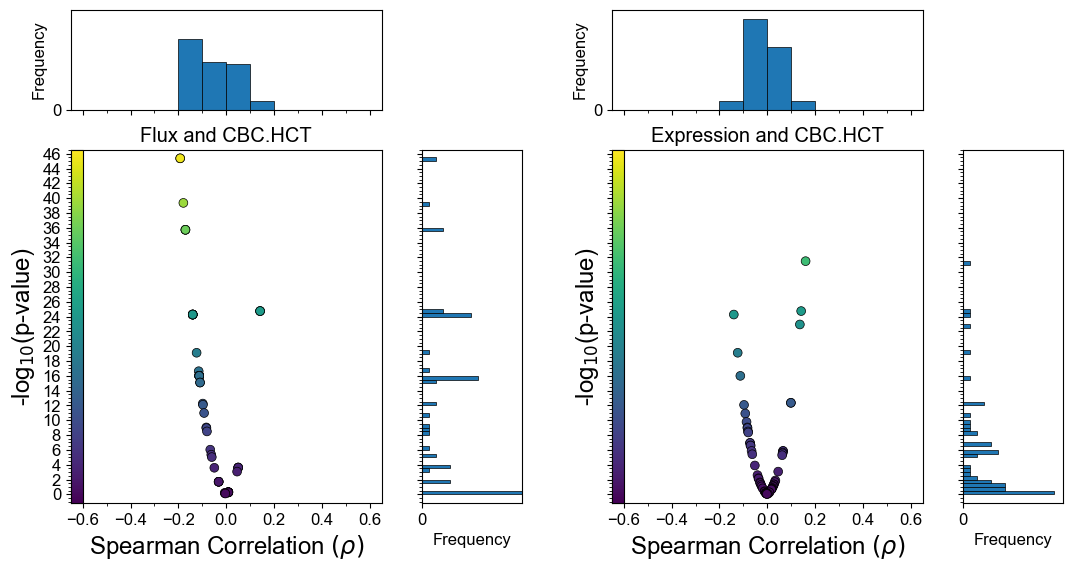

In [100]:
metadata_col = "CBC.HCT"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=2,
    ytick_minor=0.5,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)

if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### CBC.MCV

Variables                                                   Flux and CBC.MCV  \
Spearman correlation                                                     rho   
reaction genes                                                                 
INSt     SLC29A1                                                    0.135127   
ADNt     SLC29A1                                                    0.120823   
H2Ot     AQP1;AQP3                                                  0.104411   
O2t      AQP1                                                       0.100445   
NAt      GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;SCN4A;SCN9...         0.099031   
CA2t     CACNA1A;GRIA1;P2RX1;P2RX2;P2RX7;PANX1;PIEZO1;TM...         0.098990   
NH4t     AQP1;AQP3;RHAG;RHCE;RHD                                    0.097004   
ADA      ADA                                                        0.097004   
Kt1      GRIA1;KCNAB2;KCNK5;KCNN4;P2RX1;P2RX2;P2RX7;PANX...         0.096235   
PFK      PFKL;PFKM;PFKP                 

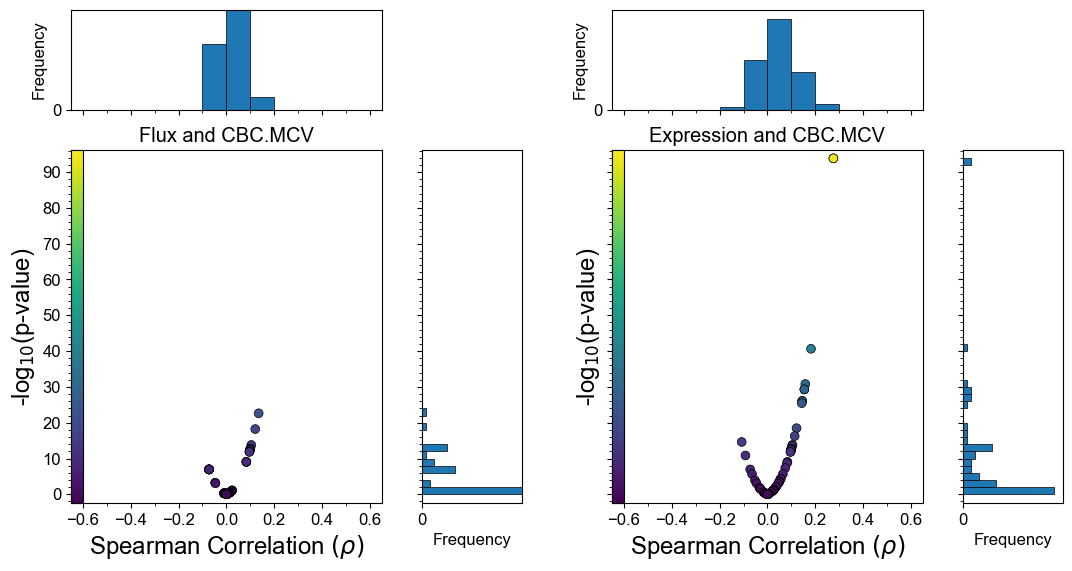

In [101]:
metadata_col = "CBC.MCV"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### CBC.RDW

Variables                                                     Flux and CBC.RDW  \
Spearman correlation                                                       rho   
reaction   genes                                                                 
PFK        PFKL;PFKM;PFKP                                            -0.124289   
TPI        TPI1                                                      -0.124289   
FBA        ALDOA;ALDOB;ALDOC                                         -0.124289   
GAPD       GAPDH;GAPDHS                                              -0.114971   
LDH_L      LDHA;LDHB                                                 -0.114971   
L_LACt2    BSG;EMB;SLC16A1;SLC16A7                                   -0.114971   
FCYTOB5OXR CYB5A;CYB5B;CYB5R3                                        -0.107899   
METHBCYTBR CYB5A;CYB5B;HBA;HBB;HBD;HBE1;HBG1;HBG2;HBM;HBQ1...        -0.107899   
OXYHBAOX   HBA;HBB;HBD;HBE1;HBG1;HBG2;HBM;HBQ1;HBZ                   -0.107899   
HB23DPGB   HBA;H

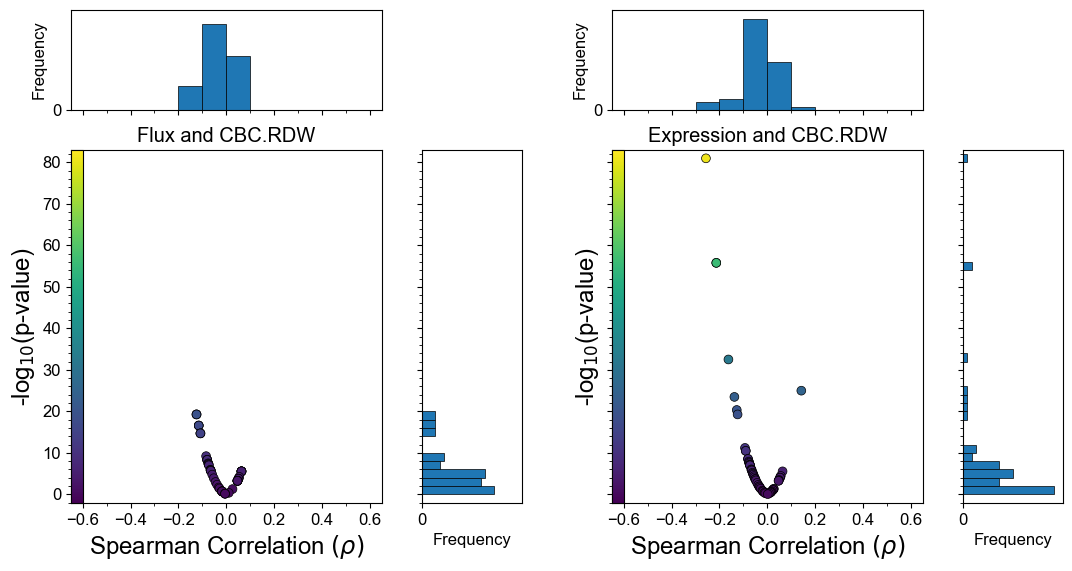

In [102]:
metadata_col = "CBC.RDW"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### CBC.PLT

Variables                                          Flux and CBC.PLT  \
Spearman correlation                                            rho   
reaction genes                                                        
HEX1     HK1;HK3                                           0.189643   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4               0.189643   
PYK      PKLR;PKM                                          0.162151   
ENO      ENO1;ENO2;ENO3                                    0.162151   
CAATPS1  ATP2B1;ATP2B4                                     0.162151   
PGK      PGK1;PGK2                                         0.162151   
NaKt     ATP1A1;ATP1A3;ATP1A4;ATP1B1;ATP1B2;ATP1B3         0.162151   
DPGase   BPGM                                              0.162151   
PGM      BPGM;PGAM1                                        0.162151   
PPM      PGM2                                              0.159537   

Variables                                                         
Spearman 

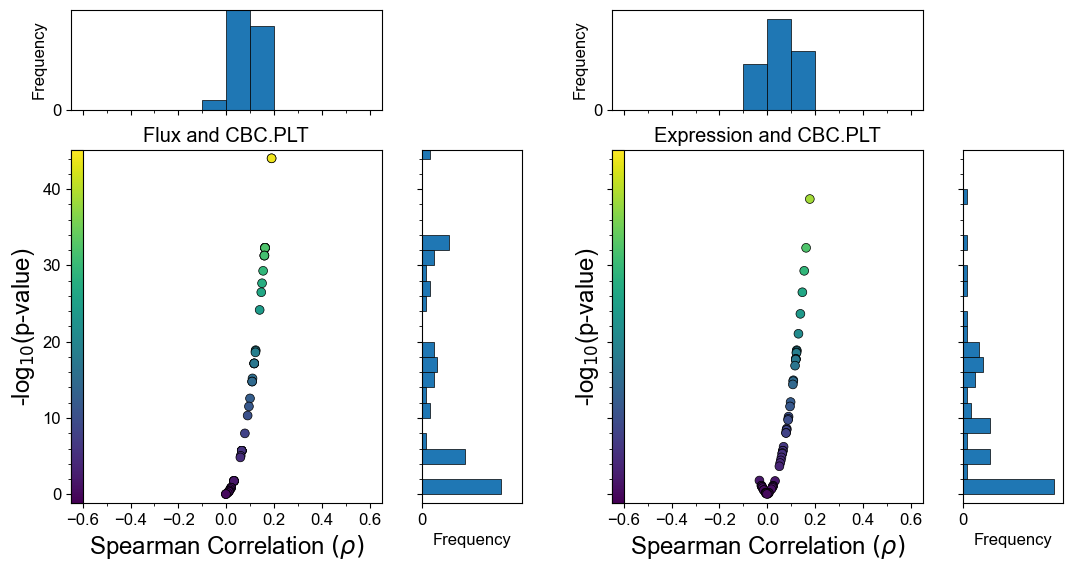

In [103]:
metadata_col = "CBC.PLT"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;

##### Ferritin

Variables                                          Flux and Ferritin  \
Spearman correlation                                             rho   
reaction genes                                                         
PYK      PKLR;PKM                                          -0.184183   
ENO      ENO1;ENO2;ENO3                                    -0.184183   
CAATPS1  ATP2B1;ATP2B4                                     -0.184183   
PGK      PGK1;PGK2                                         -0.184183   
NaKt     ATP1A1;ATP1A3;ATP1A4;ATP1B1;ATP1B2;ATP1B3         -0.184183   
DPGase   BPGM                                              -0.184183   
PGM      BPGM;PGAM1                                        -0.184183   
HEX1     HK1;HK3                                           -0.183001   
GLC_Dt   SLC2A1;SLC2A14;SLC2A2;SLC2A3;SLC2A4               -0.183001   
PYRt2    BSG;EMB;SLC16A1;SLC16A7                           -0.150386   

Variables                                                      

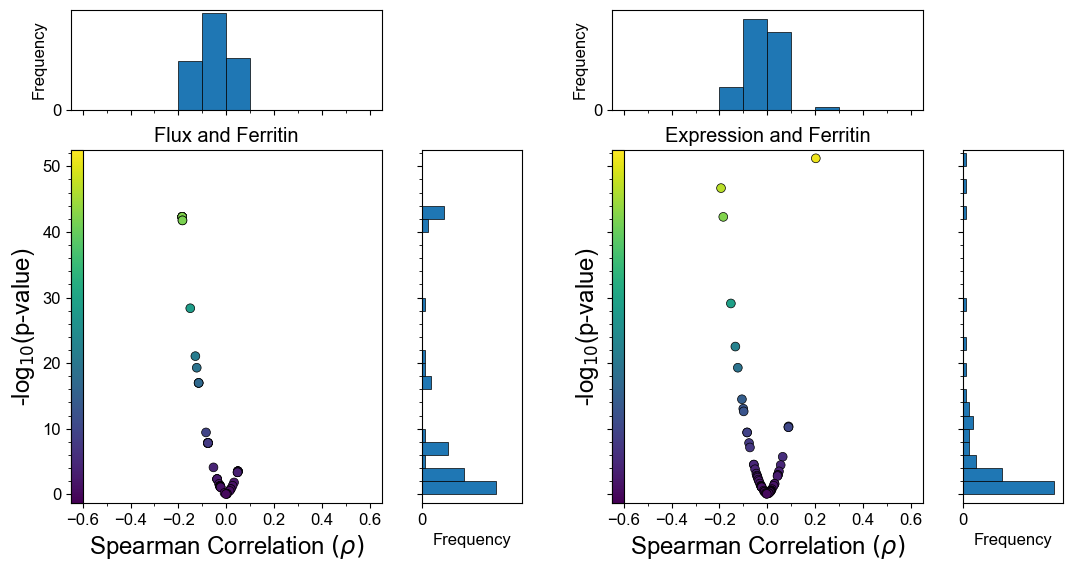

In [104]:
metadata_col = "Ferritin"
group_name = "ALL"  # Use models in visualizations
xmin, xmax = (-0.60, 0.60)
xpad = 0.05
plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=600,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=10,
    ytick_minor=2,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=600,  # Major x-tick interval for histogram aligned with y-axis
)
sharey = True


nrows, ncols = (1, 2)
fig, (ax_flux, ax_expr) = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
    sharex=True,
    sharey=sharey,
)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Flux", metadata_col))].droplevel(1).copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_flux = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


df_corr = (
    df_all_correlations.loc[:, " and ".join(("Expression", metadata_col))]
    .droplevel(1)
    .copy()
)
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr_expr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)


if sharey:
    plot_kwargs["ymax"] = max(
        df_corr_flux["pvalue"].max(), df_corr_expr["pvalue"].max()
    )

axes_flux = plot_correlations(
    df_corr_flux,
    ax=ax_flux,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
axes_expr = plot_correlations(
    df_corr_expr,
    ax=ax_expr,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines={},
    **plot_kwargs,
)
print(
    df_all_correlations.loc[
        df_corr_flux.head(display_top_nhits).index,
        [c for c in df_all_correlations.columns if c[0] == f"Flux and {metadata_col}"],
    ]
)
print()
print(
    df_all_correlations.loc[
        df_corr_expr.head(display_top_nhits).index,
        [
            c
            for c in df_all_correlations.columns
            if c[0] == f"Expression and {metadata_col}"
        ],
    ]
)
axes_flux[0].set_title(
    f"Flux and {metadata_col}",
    fontsize="x-large",
    loc="center",
)
axes_expr[0].set_title(
    f"Expression and {metadata_col}", fontsize="x-large", loc="center"
)

axes_flux[1].sharey(axes_expr[1])
axes_flux[2].sharex(axes_expr[2])
fig;